To get a sense of the whether channels are ordered properly, we can compute the correlation between channels 



In [1]:
import spikeinterface as si 
import spikeinterface.preprocessing as spre
from dataLoading_utils import getXMLData
from dataAnalysis_utils import find_repetitive_channels
import numpy as np
import spikeinterface.widgets as sw
import matplotlib.pyplot as plt
from probeinterface import Probe, ProbeGroup, generate_linear_probe, generate_multi_shank, combine_probes 
from probeinterface.plotting import plot_probe
import matplotlib

In [2]:
# potentially use multiple chunks of data in time ? 

dat_path = r"/Volumes/Trenholm2/neuroTechData/Viktor_Budapest/3170_day8_260415_170145/amplifier.dat" 
xml_path = r"/Volumes/Trenholm2/neuroTechData/Viktor_Budapest/3170_day8_260415_170145/amplifier.xml" 

channel_ids, skippedChannels, xml_data = getXMLData(xml_path)
#channel_ids_py = np.asarray(channel_ids) - 1

nBits, nChannels, samplingRate, offset, lfpSamplingRate = xml_data

samplingRate = 20000 # for viktor mouse XML is wrong

print(f"Number of bits: {nBits}, Number of channels: {nChannels}, Sampling rate: {samplingRate} Hz, Offset: {offset}, LFP sampling rate: {lfpSamplingRate} Hz")

uV_per_count = 0.195 #https://intantech.com/files/Intan_RHX_user_guide.pdf

# TODO: Voltage range ? = 10

full_recording = si.read_binary(file_paths=dat_path, sampling_frequency=samplingRate, dtype=f"int{nBits}", num_channels=nChannels, channel_ids=np.arange(nChannels), is_filtered=False, gain_to_uV=uV_per_count, offset_to_uV=0.0)

shank2_channel_ids = np.array(channel_ids[32:])
print(f"Shank 2 channel IDs: {shank2_channel_ids}")
shank2_recording = full_recording.select_channels(channel_ids=shank2_channel_ids)

print(f"Full recording duration: {shank2_recording.get_total_duration() / 60} minutes")
print("For computational efficiency, we will restrict our analysis to the first 30 minutes of the recording.")

shorter_rec_duration = 30 # minutes
RECORDING = shank2_recording.frame_slice(start_frame=0, end_frame=int(shorter_rec_duration * 60 * samplingRate))

del full_recording
del shank2_recording

%matplotlib widget

sw.plot_traces(RECORDING, channel_ids=shank2_channel_ids[:], return_in_uV=True, backend="ipywidgets")


Number of bits: 16, Number of channels: 64, Sampling rate: 20000 Hz, Offset: 0.0, LFP sampling rate: 2000.0 Hz
Shank 2 channel IDs: [55 56 54 57 53 58 52 59 51 60 50 61 49 62 48 63 47 32 46 33 45 34 44 35
 43 36 42 37 41 38 40 39]
Full recording duration: 63.23872000000001 minutes
For computational efficiency, we will restrict our analysis to the first 30 minutes of the recording.


AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

PROBE P -----------------------------------------------
[ 0.      1.1655  2.331   3.4965  4.662   5.8275  6.993   8.1585  9.324
 10.4895 11.655  12.8205 13.986  15.1515 16.317  17.4825 18.648  19.8135
 20.979  22.1445 23.31   24.4755 25.641  26.8065 27.972  29.1375 30.303
 31.4685 32.634  33.7995 34.965  36.1305]
[  0.          19.5         40.60800013  60.10800013  82.79066157
 102.29066157 126.51693917 146.01693917 171.75956778 191.25956778
 218.49495037 237.99495037 266.70307347 286.20307347 316.36744933
 335.86744933 367.47508473 386.97508473 420.01647659 439.51647659
 473.98563514 493.48563514 529.38013564 548.88013564 586.20120024
 605.70120024 644.45381217 663.95381217 704.14686477 723.64686477
 765.29334884 784.79334884]
PROBE M -----------------------------------------------
[ 0.          1.21774194  2.43548387  3.65322581  4.87096774  6.08870968
  7.30645162  8.52419355  9.74193549 10.95967742 12.17741936 13.39516129
 14.61290323 15.83064516 17.0483871  18.26612904 19.4838709

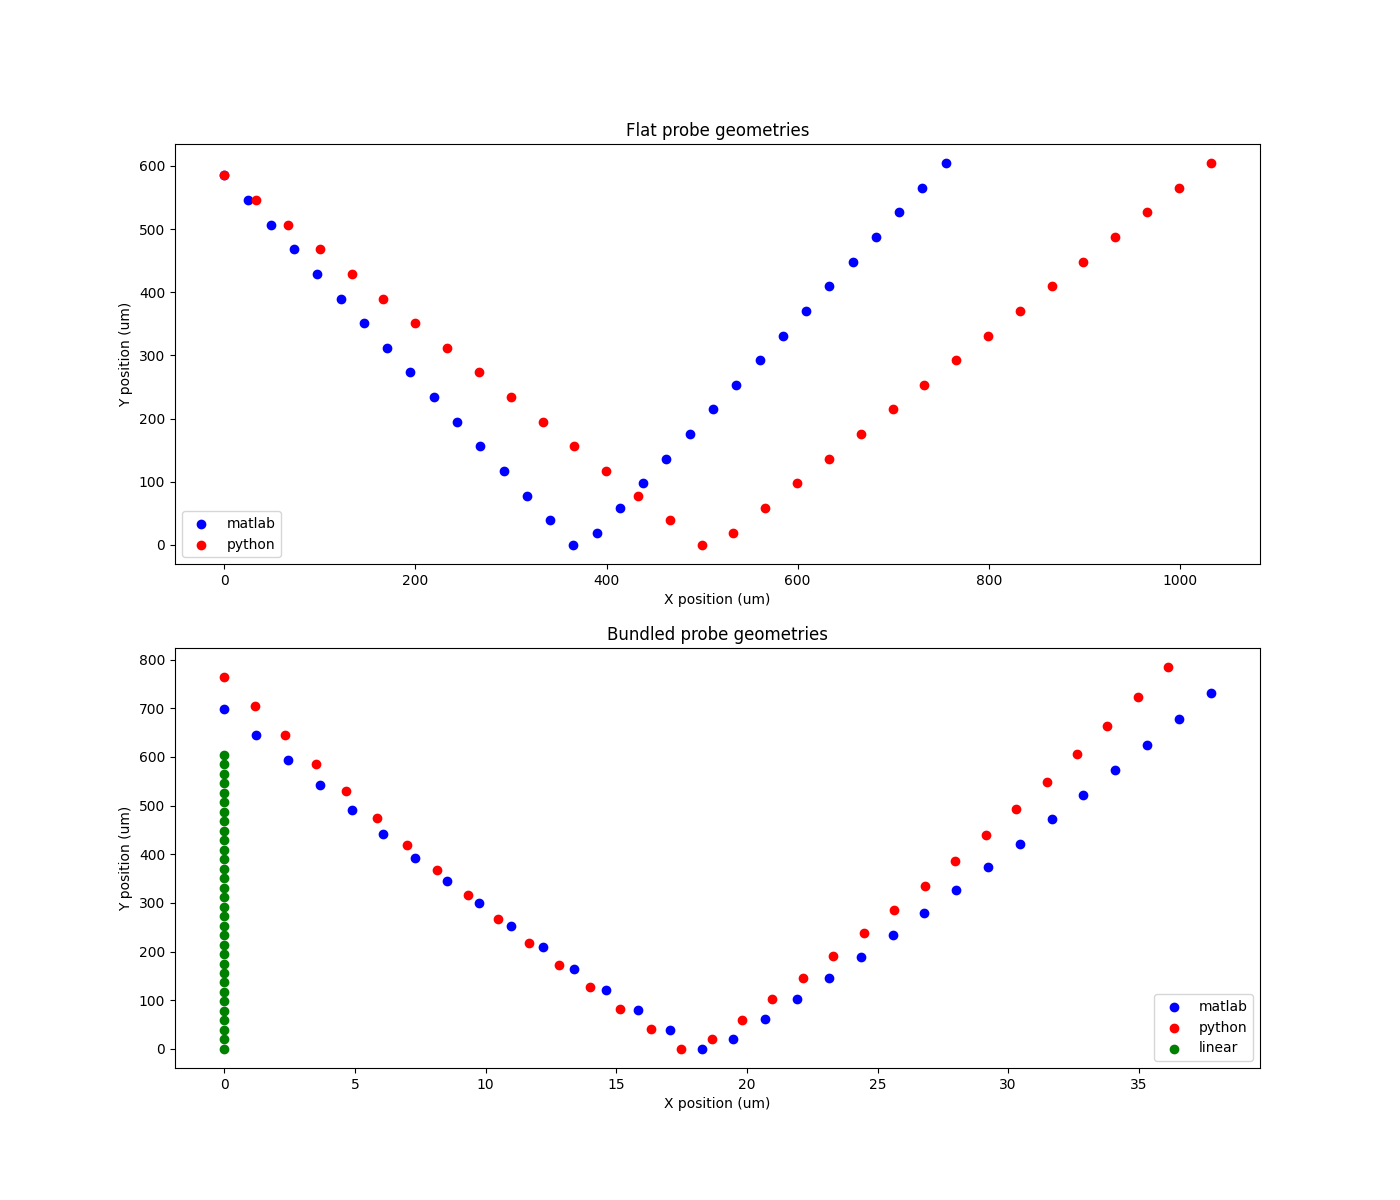

Below are the point-wise differences in coordinates between the two different geometries
[0.         0.05224194 0.10448387 0.15672581 0.20896774 0.26120968
 0.31345162 0.36569355 0.41793549 0.47017742 0.52241936 0.57466129
 0.62690323 0.67914516 0.7313871  0.78362904 0.83587097 0.88811291
 0.94035484 0.99259678 1.04483871 1.09708065 1.14932258 1.20156452
 1.25380645 1.30604839 1.35829033 1.41053226 1.4627742  1.51501613
 1.56725807 1.6195    ]
[  0.           0.56206844  -1.04593169   0.61794776  -2.56471368
  -0.29066157  -4.51693917  -1.01693917  -6.75956778  -2.25956778
  -9.49495037  -3.99495037 -13.70307347  -6.20307347 -17.36744933
  -9.86744933 -21.47508473 -12.97508473 -27.01647659 -17.51647659
 -31.98563514 -21.48563514 -38.38013564 -26.88013564 -44.20120024
 -32.70120024 -51.45381217 -38.95381217 -59.14686477 -45.64686477
 -67.29334884 -52.79334884]


In [3]:
########### PROBE 1: python script ###########

##############################################
from clean_bending_model import BundleParameters, run_from_array, create_flat_geom

# set parameters for probe geometry 
num_contact_sites = 32
y_flat_contact_dist = 19.5 # um 
x_flat_contact_dist = 33.3 # um (based on figure from https://www.nature.com/articles/s41467-024-49226-9#Sec7)
base_length = 2000.0  # choose something comfortably larger than the max y offset

# create the flat geometry for the electrode tips and the base of the probe
electrode_tips = create_flat_geom(num_contact_sites, x_flat_contact_dist, y_flat_contact_dist)
electrode_base = np.column_stack((electrode_tips[:,0], np.ones(num_contact_sites)*base_length))

c_x = np.array([-365.50,-341.15,-316.79,-292.44,-268.08,-243.73,-219.37,-195.02,-170.66,-146.31,-121.95,-97.60,-73.24,-48.89,-24.53,-0.18,24.18,48.53,72.89,97.24,121.60,145.95,170.31,194.66,219.02,243.37,267.73,292.08,316.44,340.79,365.15,389.50])
c_y = np.array([585.00,546.00,507.00,468.00,429.00, 390.00,351.00,312.00,273.00,234.00,195.00,156.00,117.00,78.00,39.00,0.00,19.50,58.50,97.50,136.50,175.50,214.50,253.50,292.50,331.50,370.50,409.50,448.50,487.50,526.50,565.50,604.50])

# model the bundling of the probe and get the new coordinates for the electrode tips and ends of the probe
#TODO: find better params ? 
params = BundleParameters(
    first_bend_distance=150.0,
    max_bend_angle_deg=45.0,
    bundle_ratio=0.035,
    first_radius=300.0,
    second_radius=300.0,
)

result = run_from_array(electrode_base, electrode_tips,params=params, make_plot=False) # positions are in result.ends and result.tips
probe_p_x = result.ends[:,0] - np.min(result.ends[:,0]) # shift x coordinates so the minimum is at 0
probe_p_y = result.ends[:,1] - np.min(result.ends[:,1]) # shift y coordinates so the minimum is at 0

np.set_printoptions(suppress=True)
print("PROBE P -----------------------------------------------")

print(np.sort(probe_p_x))
print(np.sort(probe_p_y))

probe_p = Probe(ndim=2, si_units='um')
probe_p.set_contacts(positions=np.column_stack((probe_p_x, probe_p_y)), shapes=np.array(['square'] * num_contact_sites), shape_params={"width": 13})
# set the contact IDs for each site 
probe_p.set_device_channel_indices(np.arange(num_contact_sites))
probe_p.set_contact_ids(shank2_channel_ids)
probe_p.create_auto_shape()

# plot the probe geometry to check it looks correct
#plot_probe(probe_p, with_contact_id=True, with_device_index=True)
    
# link the probe geometry to our recording object 
shank2_probe_p = RECORDING.set_probe(probe_p, in_place=False)


########### PROBE 2: MATLAB script ###########

##############################################
siteLoc = np.array([(37.75, 732), ( 0, 698), ( 36.53225807, 678), ( 1.21774194, 645), ( 35.31451613, 625), ( 2.43548387, 593), ( 34.0967742, 573), ( 3.65322581, 542), ( 32.87903226, 522), ( 4.87096774, 491), ( 31.66129033, 472), ( 6.08870968, 442), ( 30.44354839, 422), ( 7.30645162, 393), ( 29.22580645, 374), ( 8.524193551, 346), ( 28.008064519, 326), ( 9.741935487, 299), ( 26.790322584, 280), ( 10.959677422, 253), ( 25.572580648, 234), ( 12.177419358, 209), ( 24.354838713, 189), ( 13.395161293, 165), ( 23.137096777, 145), ( 14.612903229, 122), ( 21.919354842, 102), ( 15.830645164, 80.22594789), ( 20.701612906, 60.72594789), ( 17.0483871, 39.56206844), ( 19.483870971, 20.06206844), ( 18.266129035, 0), ( 3037.75, 732), ( 3000, 698), ( 3036.53225807, 678), ( 3001.21774194, 645), ( 3035.31451613, 625), ( 3002.43548387, 593), ( 3034.0967742, 573), ( 3003.65322581, 542), ( 3032.87903226, 522), ( 3004.87096774, 491), ( 3031.66129033, 472), ( 3006.08870968, 442), ( 3030.44354839, 422), ( 3007.30645162, 393), ( 3029.22580645, 374), ( 3008.524193551, 346), ( 3028.008064519, 326), ( 3009.741935487, 299), ( 3026.790322584, 280), ( 3010.959677422, 253), ( 3025.572580648, 234), ( 3012.177419358, 209), ( 3024.354838713, 189), ( 3013.395161293, 165), ( 3023.137096777, 145), ( 3014.612903229, 122), ( 3021.919354842, 102), ( 3015.830645164, 80.22594789), ( 3020.701612906, 60.72594789), ( 3017.0483871, 39.56206844), ( 3019.483870971, 20.06206844), ( 3018.266129035, 0)])
#siteMap = [8, 9, 7, 10, 6, 11, 5, 12, 4, 13, 3, 14, 2, 15, 1, 16, 32, 17, 31, 18, 30, 19, 29, 20, 28, 21, 27, 22, 26, 23, 25, 24, 56, 57, 55, 58, 54, 59, 53, 60, 52, 61, 51, 62, 50, 63, 49, 64, 48, 33, 47, 34, 46, 35, 45, 36, 44, 37, 43, 38, 42, 39, 41, 40] # MATLAB INDEXING

#m_coord_hand = np.array([[19.3065, 732.022], [-18.4435, 697.77], [18.0887, 678.27], [-17.2258, 644.867], [16.871, 625.367], [-16.0081, 592.82], [15.6532, 573.32], [-14.7903, 541.636], [14.4355, 522.136], [-13.5726, 491.324], [13.2177, 471.824], [-12.3548, 441.895], [12, 422.395], [-11.1371, 393.363], [10.7823, 373.863], [-9.91935, 345.743], [9.56452, 326.243], [-8.70161, 299.05], [8.34677, 279.55], [-7.48387, 253.304], [7.12903, 233.804], [-6.26613, 208.525], [5.91129, 189.025], [-5.04839, 164.735], [4.69355, 145.235], [-3.83065, 121.96], [3.47581, 102.46], [-2.6129, 80.2259], [2.25806, 60.7259], [-1.39516, 39.5621], [1.04032, 20.0621], [-0.177419, 0]])

probe_m_x = siteLoc[32:,0] - np.min(siteLoc[32:,0]) # shift x coordinates so the minimum is at 0
probe_m_y = siteLoc[32:,1] - np.min(siteLoc[32:,1]) # shift y coordinates so the minimum is at 0

np.set_printoptions(suppress=True)
print("PROBE M -----------------------------------------------")
print(np.sort(probe_m_x))
print(np.sort(probe_m_y))


probe_m = Probe(ndim=2, si_units='um')
probe_m.set_contacts(positions=np.column_stack((probe_m_x, probe_m_y)), shapes=np.array(['square'] * num_contact_sites), shape_params={"width": 13})
# set the contact IDs for each site 
probe_m.set_device_channel_indices(np.arange(num_contact_sites))
probe_m.set_contact_ids(shank2_channel_ids)
probe_m.create_auto_shape()

# plot the probe geometry to check it looks correct
#plot_probe(probe_m, with_contact_id=True, with_device_index=True)
    
# link the probe geometry to our recording object 
shank2_probe_m = RECORDING.set_probe(probe_m, in_place=False)

########### PROBE 3: LINEAR ###########

##############################################

probe_l_x = np.zeros(32)
probe_l_y = np.arange(32) * 19.5

np.set_printoptions(suppress=True)
print("PROBE L -----------------------------------------------")
print(np.sort(probe_l_x))
print(np.sort(probe_l_y))


probe_l = Probe(ndim=2, si_units='um')
probe_l.set_contacts(positions=np.column_stack((probe_l_x, probe_l_y)), shapes=np.array(['square'] * num_contact_sites), shape_params={"width": 13})
# set the contact IDs for each site 
probe_l.set_device_channel_indices(np.arange(num_contact_sites))
probe_l.set_contact_ids(shank2_channel_ids)
probe_l.create_auto_shape()

# plot the probe geometry to check it looks correct
#plot_probe(probe_m, with_contact_id=True, with_device_index=True)
    
# link the probe geometry to our recording object 
shank2_probe_l = RECORDING.set_probe(probe_l, in_place=False)

# compare the three probe geometries 

fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=False)
axes[0].scatter(c_x + np.abs(np.min(c_x)), c_y, color='blue', label='matlab')
axes[0].scatter(electrode_tips[:,0], electrode_tips[:,1], color='red', label='python')
axes[0].set_xlabel('X position (um)')
axes[0].set_ylabel('Y position (um)')
axes[0].set_title("Flat probe geometries")
axes[0].legend()
axes[1].scatter(probe_m.contact_positions[:,0], probe_m.contact_positions[:,1], label='matlab', color='blue')
axes[1].scatter(probe_p.contact_positions[:,0], probe_p.contact_positions[:,1], label='python', color='red')
axes[1].scatter(probe_l._contact_positions[:,0], probe_l.contact_positions[:,1], label='linear', color='green')
axes[1].set_xlabel('X position (um)')
axes[1].set_ylabel('Y position (um)')
axes[1].set_title('Bundled probe geometries')
axes[1].legend()    
plt.show()

# print differences
print("Below are the point-wise differences in coordinates between the two different geometries") 
print(np.sort(probe_m_x) - np.sort(probe_p_x))
print(np.sort(probe_m_y) - np.sort(probe_p_y))

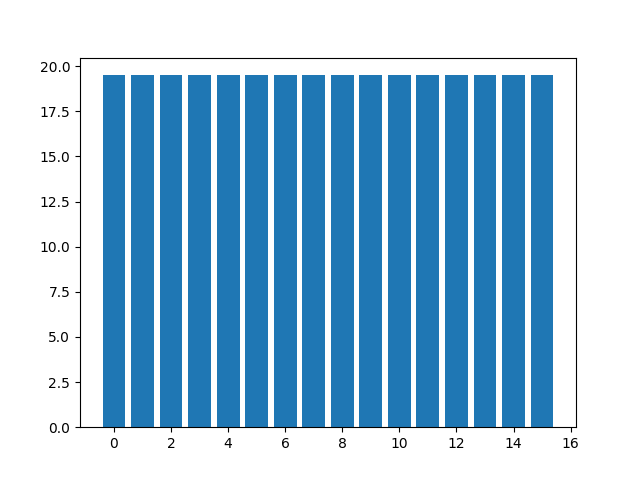

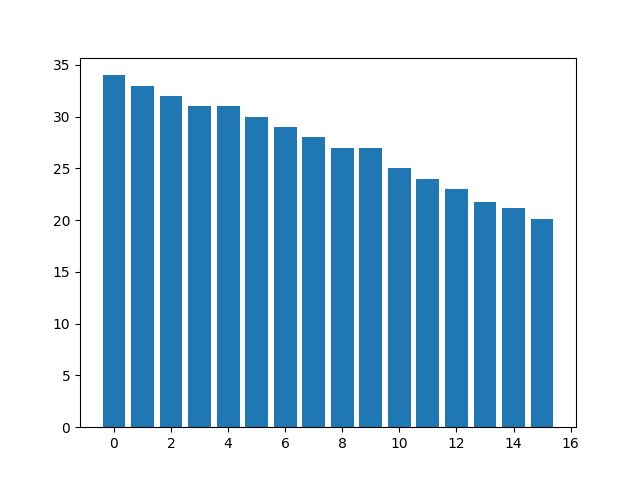

[19.5 19.5 19.5 19.5 19.5 19.5 19.5 19.5 19.5 19.5 19.5 19.5 19.5 19.5
 19.5 19.5]
[34.         33.         32.         31.         31.         30.
 29.         28.         27.         27.         25.         24.
 23.         21.77405211 21.16387945 20.06206844]


In [5]:
plt.figure()
plt.bar(np.arange(16), probe_p_y[::2] - probe_p_y[1::2])
plt.show()

plt.figure()
plt.bar(np.arange(16), probe_m_y[::2] - probe_m_y[1::2])
plt.show()

print(probe_p_y[::2] - probe_p_y[1::2])
print(probe_m_y[::2] - probe_m_y[1::2])


Shank 2 channels to skip: [36 62]


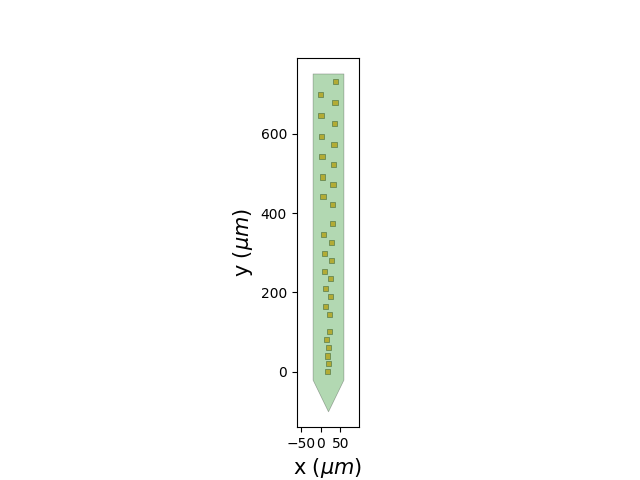

In [4]:
# remove noisy channels :) 

# STEP 1: remove channels already identified as bad in the xml file
shank2_skipped_channels = np.intersect1d(shank2_channel_ids, skippedChannels)
print(f"Shank 2 channels to skip: {shank2_skipped_channels}")  

shank2_skipped_channels = np.intersect1d(shank2_channel_ids, skippedChannels)

m_rec_clean = shank2_probe_m.remove_channels(shank2_skipped_channels)
p_rec_clean = shank2_probe_p.remove_channels(shank2_skipped_channels)
l_rec_clean = shank2_probe_l.remove_channels(shank2_skipped_channels)
clean_channel_ids = m_rec_clean.get_channel_ids()

sw.plot_probe_map(m_rec_clean)

######## SHANK M ###########
[ 6  8  8  9  9 11 11 11 12 11 11 10 12 12 11 11 11 11 11 11 12 12 12 12
 11  9  8  6  6  5]
min: 5
median: 11.0
max: 12
######## SHANK P ###########
[ 6  7  7  8  9 10 11 10 10 10 11 10 12 11 10 10 11  9 10 11 12 12 12 12
 10  8  8  7  6  6]
min: 6
median: 10.0
max: 12


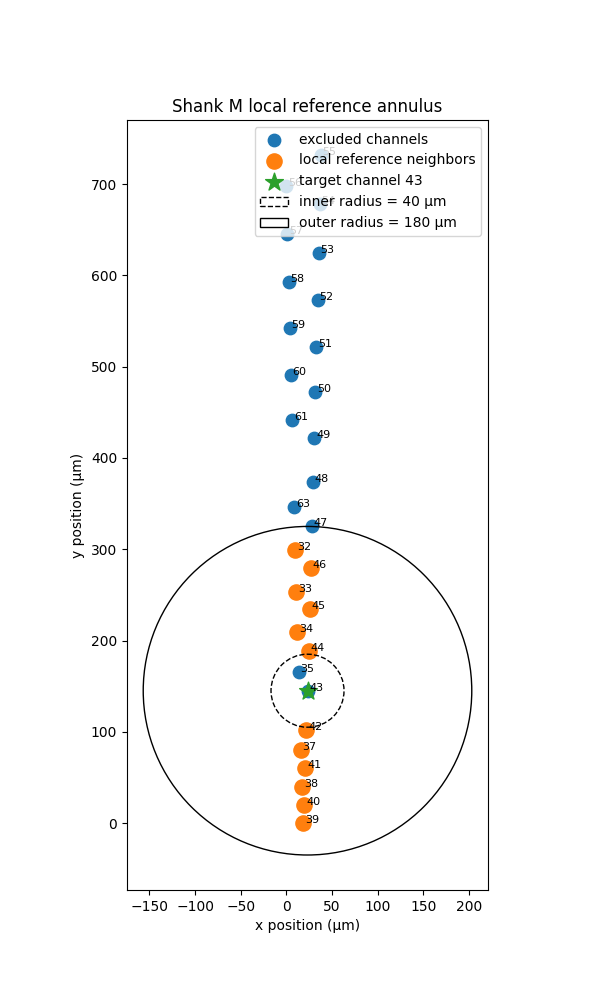

Target channel: 43
Neighbor channels: [32 46 33 45 34 44 42 37 41 38 40 39]
Number of neighbors: 12
Inner, Outer: (40, 180)


In [6]:
from scipy.spatial.distance import cdist

inner, outer = 40, 180

print("######## SHANK M ###########") 
locs = m_rec_clean.get_channel_locations()
D = cdist(locs, locs)

counts = ((D > inner) & (D <= outer)).sum(axis=1)

print(counts)
print("min:", counts.min())
print("median:", np.median(counts))
print("max:", counts.max())

print("######## SHANK P ###########") 
locs = p_rec_clean.get_channel_locations()
D = cdist(locs, locs)

counts = ((D > inner) & (D <= outer)).sum(axis=1)

print(counts)
print("min:", counts.min())
print("median:", np.median(counts))
print("max:", counts.max())

def plot_local_reference_annulus(recording, sample_channel=None, inner=40, outer=180, title=None):
    locs = recording.get_channel_locations()
    channel_ids = np.asarray(recording.channel_ids)

    # choose middle channel if none provided
    if sample_channel is None:
        sample_idx = len(channel_ids) // 2
    else:
        sample_idx = np.where(channel_ids == sample_channel)[0][0]

    center = locs[sample_idx]
    D = cdist(locs, locs)
    neighbors = (D[sample_idx] > inner) & (D[sample_idx] <= outer)

    fig, ax = plt.subplots(figsize=(6, 10))

    # all contacts
    ax.scatter(locs[:, 0], locs[:, 1], s=80, label="excluded channels")

    # selected annulus neighbors
    ax.scatter(
        locs[neighbors, 0],
        locs[neighbors, 1],
        s=120,
        label="local reference neighbors",
    )

    # center channel
    ax.scatter(
        center[0],
        center[1],
        s=180,
        marker="*",
        label=f"target channel {channel_ids[sample_idx]}",
    )

    # inner and outer radius circles
    inner_circle = plt.Circle(center, inner, fill=False, linestyle="--", label=f"inner radius = {inner} µm")
    outer_circle = plt.Circle(center, outer, fill=False, linestyle="-", label=f"outer radius = {outer} µm")

    ax.add_patch(inner_circle)
    ax.add_patch(outer_circle)

    # labels
    for ch, (x, y) in zip(channel_ids, locs):
        ax.text(x + 2, y, str(ch), fontsize=8)

    ax.set_aspect("equal")
    ax.set_xlabel("x position (µm)")
    ax.set_ylabel("y position (µm)")
    ax.set_title(title or f"Local reference annulus around channel {channel_ids[sample_idx]}")
    ax.legend(loc="best")
    plt.show()

    print("Target channel:", channel_ids[sample_idx])
    print("Neighbor channels:", channel_ids[neighbors])
    print("Number of neighbors:", neighbors.sum())



plot_local_reference_annulus(
    m_rec_clean,
    sample_channel=43,  # middle channel
    inner=inner,
    outer=outer,
    title="Shank M local reference annulus"
)
print(f"Inner, Outer: {inner, outer}")

In [5]:
# common preprocessing before two shanks are applied

prePros_m = {}
prePros_p = {}
prePros_l = {}

for rec, out in zip([m_rec_clean, p_rec_clean, l_rec_clean], [prePros_m, prePros_p, prePros_l]):
    P1 = si.preprocessing.center(rec, mode='median', dtype='float32')
    P2 = si.preprocessing.highpass_filter(P1, freq_min=300.0) # TODO: consider bandpass 
    #P3_glob = si.preprocessing.common_reference(recording = P2, reference = 'global', operator='median') 
    P3_loc = si.preprocessing.common_reference(recording = P2, reference='local', operator='median', local_radius=(40, 180), min_local_neighbors=5)
    #P4_z = si.preprocessing.zscore(P3_loc, mode="median+mad")
    P4_loc = si.preprocessing.whiten(P3_loc, mode="local", radius_um=100) 

    out.update({"P1":P1, "P2":P2, "P3_loc":P3_loc, "P4_loc": P4_loc})

In [7]:
sw.plot_traces(prePros_m["P3_loc"], return_in_uV=True, backend="ipywidgets")
sw.plot_traces(prePros_m["P4_z"], return_in_uV=True, backend="ipywidgets")


AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def lateral_order_indices(channel_ids):
    """
    Reorders by position, not channel ID value:
    odd positions ascending, then even positions descending.
    """
    n = len(channel_ids)
    odd_idx = list(range(1, n, 2))
    even_idx = list(range(0, n, 2))[::-1]
    return odd_idx + even_idx


def plot_channel_stats_chunked(
    recording,
    chunk_s=60,
    segment_index=0,
    return_in_uV=True,
    mode_bins=200,
    percentiles=(1, 99),
):
    fs = recording.get_sampling_frequency()
    n_frames = recording.get_num_frames(segment_index=segment_index)
    channel_ids = np.asarray(recording.get_channel_ids())

    chunk_frames = int(chunk_s * fs)
    starts = np.arange(0, n_frames, chunk_frames)
    centers_min = (starts + chunk_frames / 2) / fs / 60

    n_chunks = len(starts)
    n_channels = len(channel_ids)

    stats = {
        "min": np.empty((n_chunks, n_channels)),
        "max": np.empty((n_chunks, n_channels)),
        "median": np.empty((n_chunks, n_channels)),
        "mean": np.empty((n_chunks, n_channels)),
        "approx_mode": np.empty((n_chunks, n_channels)),
    }

    for i, start in enumerate(starts):
        end = min(start + chunk_frames, n_frames)

        traces = recording.get_traces(
            start_frame=start,
            end_frame=end,
            segment_index=segment_index,
            return_in_uV=return_in_uV,
        )

        stats["min"][i] = traces.min(axis=0)
        stats["max"][i] = traces.max(axis=0)
        stats["median"][i] = np.median(traces, axis=0)
        stats["mean"][i] = traces.mean(axis=0)

        for ch in range(n_channels):
            counts, edges = np.histogram(traces[:, ch], bins=mode_bins)
            k = np.argmax(counts)
            stats["approx_mode"][i, ch] = 0.5 * (edges[k] + edges[k + 1])

        lateral_idx = lateral_order_indices(channel_ids)
    lateral_channel_ids = channel_ids[lateral_idx]

    fig, axes = plt.subplots(
        len(stats),
        3,
        figsize=(25, 20),
        sharex="col",
        gridspec_kw={
            "width_ratios": [1, 1, 0.04],
            "wspace": 0.25,
            "hspace": 0.45,
        },
    )

    for row, (name, values) in enumerate(stats.items()):
        img_depth = values.T
        img_lateral = img_depth[lateral_idx, :]

        vmin, vmax = np.percentile(img_depth, percentiles)

        depth_labels = np.arange(n_channels)
        lateral_labels = np.asarray(lateral_idx)

        axes[row, 0].imshow(
            img_depth,
            aspect="auto",
            origin="lower",
            extent=[centers_min[0], centers_min[-1], -0.5, n_channels - 0.5],
            vmin=vmin,
            vmax=vmax,
        )

        im1 = axes[row, 1].imshow(
            img_lateral,
            aspect="auto",
            origin="lower",
            extent=[centers_min[0], centers_min[-1], -0.5, n_channels - 0.5],
            vmin=vmin,
            vmax=vmax,
        )

        axes[row, 0].set_title(f"{name} — depth order")
        axes[row, 1].set_title(f"{name} — lateral order")

        axes[row, 0].set_ylabel("Depth order\nchannel ID")
        axes[row, 1].set_ylabel("Lateral order\nchannel ID")

        axes[row, 0].set_yticks(np.arange(n_channels))
        axes[row, 0].set_yticklabels(depth_labels, fontsize=6)

        axes[row, 1].set_yticks(np.arange(n_channels))
        axes[row, 1].set_yticklabels(lateral_labels, fontsize=6)

        # colorbar in separate far-right axis
        cbar = fig.colorbar(im1, cax=axes[row, 2])
        cbar.set_label(name)

    axes[-1, 0].set_xlabel("Time [min]")
    axes[-1, 1].set_xlabel("Time [min]")

    # Hide x-axis of colorbar column
    for row in range(len(stats)):
        axes[row, 2].set_xlabel("")
        axes[row, 2].set_ylabel(name)

    plt.tight_layout()
    plt.show()

    return stats, centers_min, channel_ids, lateral_channel_ids

"""stats, centers_min, channel_ids, lateral_channel_ids = plot_channel_stats_chunked(
    prePros_m["P4_loc"],
    chunk_s=15,
    return_in_uV=True,
)"""

'stats, centers_min, channel_ids, lateral_channel_ids = plot_channel_stats_chunked(\n    prePros_m["P4_loc"],\n    chunk_s=15,\n    return_in_uV=True,\n)'

`get_noise_levels` 
- internally called `get_random_sample_slices` with default 
  - num_chunks_per_segment=20
  - chunk_duration="500ms"
  - method="full_random"

20 random 500ms chunks are chosen at random 

noise is computed by default with method "mad" (median absolute deviation) 
- med = np.median(one_chunk, axis=0, keepdims=True)
- noise_levels = np.median(np.abs(one_chunk - med), axis=0) / 0.6744897501960817

**assumption is gaussian noise 

one noise estimate is obtained per chunk and these are averaged across chunks such that the final value is one per channel 

In [ ]:
import os

run_noise = False

if run_noise: 
    title = "probeM_P4z_meanNoise_100Runs"
    SAVE_NPY = True
    runs = 100 
    noise_levels_all = []

    for i in range(runs):
        noise_levels = si.get_noise_levels(
            prePros_m["P4_z"],
            return_in_uV=True,
            force_recompute=True)
        
        noise_levels_all.append(noise_levels)

    noise_levels_all = np.asarray(noise_levels_all)
    channels = np.arange(noise_levels_all.shape[1])

    noise_std = np.std(noise_levels_all, axis=0)
    noise_mean = np.mean(noise_levels_all, axis=0)
    if SAVE_NPY: np.save((title +  ".npy"), noise_mean)

    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

    # 1. Scatter plot across runs
    for i in range(runs):
        axes[0].scatter(
            channels,
            noise_levels_all[i],
            s=10,
            alpha=0.5)

    axes[0].set_ylabel("Noise level (uV)")
    axes[0].set_title(f"Noise levels across channels over {runs} runs")

    # 2. Boxplot per channel
    axes[1].boxplot(
        noise_levels_all,
        positions=channels,
        showfliers=False,
    )

    axes[1].set_ylabel("Noise level (uV)")
    axes[1].set_title("Noise level variability across runs")

    # 3. Std across runs
    axes[2].bar(channels, noise_std)
    axes[2].set_xlabel("Channel")
    axes[2].set_ylabel("Std across runs (uV)")
    axes[2].set_title("Noise estimate variability across runs")

    plt.suptitle(title)

    plt.tight_layout()
    plt.show()

In [27]:
traces_P3 = prePros_l["P3_loc"].get_traces(
    start_frame=0,
    end_frame=int(10 * prePros_m["P4_loc"].get_sampling_frequency()),
    return_in_uV=True)

print("-------------- P3 --------------")
print("min:", traces_P3.min())
print("max:", traces_P3.max())
print("1st percentile:", np.percentile(traces_P3, 1))
print("0.1 percentile:", np.percentile(traces_P3, 0.1))

mad = np.median(np.abs(traces_P3 - np.median(traces_P3, axis=0)), axis=0)
robust_sigma = mad / 0.6745

print("median robust sig", np.median(robust_sigma))
print("percentile robust, 1, 5, 50, 95, 99", np.percentile(robust_sigma, [1, 5, 50, 95, 99]))

traces_P4 = prePros_l["P4_loc"].get_traces(
    start_frame=0,
    end_frame=int(10 * prePros_m["P4_loc"].get_sampling_frequency()))#,return_in_uV=True)

print("-------------- P4 --------------")
print("min:", traces_P4.min())
print("max:", traces_P4.max())
print("1st percentile:", np.percentile(traces_P4, 1))
print("0.1 percentile:", np.percentile(traces_P4, 0.1))

mad = np.median(np.abs(traces_P4 - np.median(traces_P4, axis=0)), axis=0)
robust_sigma = mad / 0.6745
print("median robust sig", np.median(robust_sigma))
print("percentile robust, 1, 5, 50, 95, 99", np.percentile(robust_sigma, [1, 5, 50, 95, 99]))


-------------- P3 --------------
min: -140.68555
max: 129.21791
1st percentile: -26.501148
0.1 percentile: -42.158615
median robust sig 10.86326
percentile robust, 1, 5, 50, 95, 99 [ 5.79973733  6.92243538 10.86326027 12.41834884 12.55521157]
-------------- P4 --------------
min: -10.009607
max: 15.990613
1st percentile: -2.409319
0.1 percentile: -3.4565578
median robust sig 0.9801175
percentile robust, 1, 5, 50, 95, 99 [0.83563642 0.91095059 0.9801175  1.020086   1.02204071]


In [29]:
# detect peaks from both sorting methods 
from spikeinterface.sortingcomponents.peak_detection import detect_peaks

calculate = True
detection_thresh = 20


if calculate:
    #common_peaks = detect_peaks(recording=shank2_probe_p, method='by_channel', peak_sign='neg', detect_threshold=4, exclude_sweep_ms=0.2, noise_levels=noise_levels)
    #np.save("common_peaks_thresh_4", common_peaks)

    mean_noise_levels_l = np.load("/Users/brunebettler/Desktop/Programming_Projects/NeuroTech/SpikeExplore/Viktor_08/npy/probeL_P3LocCMR_meanNoise_100Runs.npy")
    #mean_noise_levels_m = np.load("/Users/brunebettler/Desktop/Programming_Projects/NeuroTech/SpikeExplore/Viktor_08/npy/probeM_P3LocCMR_meanNoise_100Runs.npy")
    #mean_noise_levels_p = np.load("/Users/brunebettler/Desktop/Programming_Projects/NeuroTech/SpikeExplore/Viktor_08/npy/probeP_P3LocCMR_meanNoise_100Runs.npy")

    peaks_l = detect_peaks(recording=prePros_l["P4_loc"], method='locally_exclusive', peak_sign='neg', detect_threshold=detection_thresh, exclude_sweep_ms=0.2, noise_levels=mean_noise_levels_l)
    np.save(f"Viktor_08/npy/P3_local_peaks_thresh_{detection_thresh}_l", peaks_l)

    #peaks_p = detect_peaks(recording=prePros_p["P4_loc"], method='locally_exclusive', peak_sign='neg', detect_threshold=detection_thresh, exclude_sweep_ms=0.2, noise_levels=mean_noise_levels_p)
    #np.save(f"Viktor_08/npy/P3_local_peaks_thresh_{detection_thresh}_p", peaks_p)


    #peaks_m = np.load(f"Viktor_08/npy/P3_local_peaks_thresh_{detection_thresh}_m.npy")
    #peaks_p = np.load(f"Viktor_08/npy/P3_local_peaks_thresh_{detection_thresh}_p.npy")


#print(f"peaks M shape: {peaks_m.shape}")
#print(f"peaks P shape: {peaks_p.shape}")

"""set_m = set(zip(peaks_m["sample_index"][1000:], peaks_m["channel_index"]))
set_p = set(zip(peaks_p["sample_index"], peaks_p["channel_index"]))

both = set_m & set_p
only_m = set_m - set_p
only_p = set_p - set_m

print("Both:", len(both))
print("Only m:", len(only_m))
print("Only p:", len(only_p))"""


/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/sortingcomponents/peak_detection/main.py:60: UserWarning: The signature of detect_peaks() has changed, now method_kwargs and job_kwargs are dinstinct params.This warning will raise an error in version 0.105.0
  warnings.warn(


detect peaks (locally_exclusive) (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

'set_m = set(zip(peaks_m["sample_index"][1000:], peaks_m["channel_index"]))\nset_p = set(zip(peaks_p["sample_index"], peaks_p["channel_index"]))\n\nboth = set_m & set_p\nonly_m = set_m - set_p\nonly_p = set_p - set_m\n\nprint("Both:", len(both))\nprint("Only m:", len(only_m))\nprint("Only p:", len(only_p))'

Both: 167
Only m: 36
Only p: 34


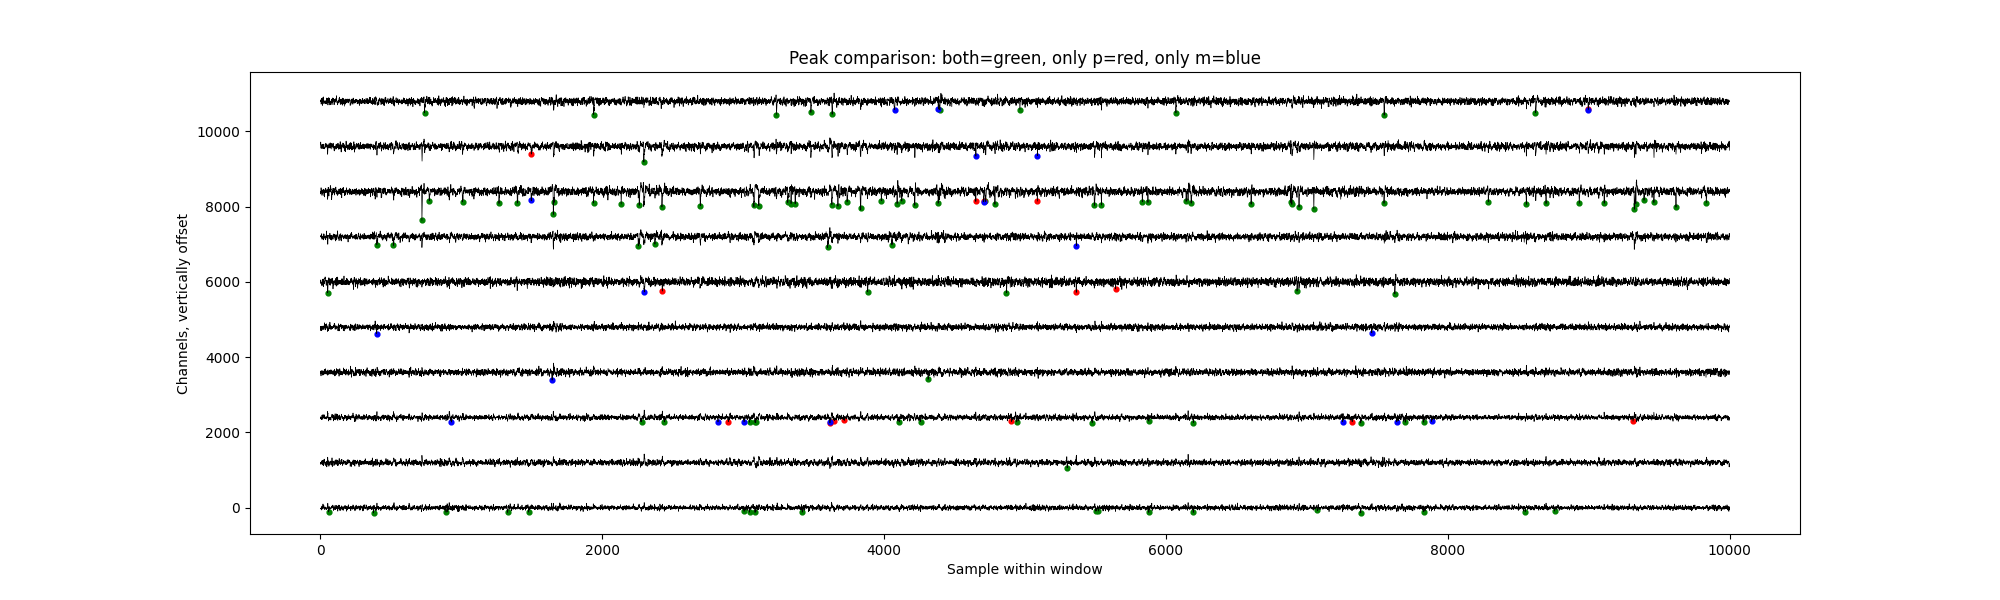

In [60]:
fs = prePros_m["P3_loc"].get_sampling_frequency()
start_s = 10
duration_s = 0.5

start = int(start_s * fs)
end = int((start_s + duration_s) * fs)

traces = prePros_m["P3_loc"].get_traces(start_frame=start, end_frame=end)

# Window peaks
mask_m = (peaks_m["sample_index"] >= start) & (peaks_m["sample_index"] < end)
mask_p = (peaks_p["sample_index"] >= start) & (peaks_p["sample_index"] < end)

peaks_m_win = peaks_m[mask_m]
peaks_p_win = peaks_p[mask_p]

# Convert to sets of (sample_index, channel_index)
set_m = set(zip(peaks_m_win["sample_index"], peaks_m_win["channel_index"]))
set_p = set(zip(peaks_p_win["sample_index"], peaks_p_win["channel_index"]))

both = set_m & set_p
only_m = set_m - set_p
only_p = set_p - set_m

print("Both:", len(both))
print("Only m:", len(only_m))
print("Only p:", len(only_p))

num_ch = 10
offset = 1200

plt.figure(figsize=(20, 6))

for ch in range(num_ch):
    plt.plot(traces[:, ch] + ch * offset, color="black", linewidth=0.5)

    # both methods: green
    for sample, chan in both:
        if chan == ch:
            t = sample - start
            plt.scatter(t, traces[t, ch] + ch * offset, color="green", s=12)

    # only p: red
    for sample, chan in only_p:
        if chan == ch:
            t = sample - start
            plt.scatter(t, traces[t, ch] + ch * offset, color="red", s=12)

    # only m: blue
    for sample, chan in only_m:
        if chan == ch:
            t = sample - start
            plt.scatter(t, traces[t, ch] + ch * offset, color="blue", s=12)

plt.title("Peak comparison: both=green, only p=red, only m=blue")
plt.xlabel("Sample within window")
plt.ylabel("Channels, vertically offset")
plt.show()

In [39]:
from spikeinterface.sortingcomponents.peak_localization import localize_peaks

job_kwargs = dict(chunk_duration='10s', n_jobs=2, progress_bar=True)

peak_locations_m = localize_peaks(
    recording=prePros_m["P3_loc"],
    peaks=peaks_m,
    method='center_of_mass',
    job_kwargs=job_kwargs,
)
np.save("Viktor_08/P3Loc_peak_locations_CM_20_m", peak_locations_m)

peak_locations_p = localize_peaks(
    recording=prePros_p["P3_loc"],
    peaks=peaks_p,
    method='center_of_mass', 
    job_kwargs=job_kwargs)

np.save("Viktor_08/P3Loc_peak_locations_CM_20_p", peak_locations_p)

localize peaks (center_of_mass) (workers: 2 processes spawn):   0%|          | 0/180 [00:00<?, ?it/s]

localize peaks (center_of_mass) (workers: 2 processes spawn):   0%|          | 0/180 [00:00<?, ?it/s]

In [8]:
peaks_m = np.load(f"Viktor_08/npy/P3_local_peaks_thresh_20_m.npy")
peaks_p = np.load(f"Viktor_08/npy/P3_local_peaks_thresh_20_p.npy")

peak_locations_m = np.load("/Users/brunebettler/Desktop/Programming_Projects/NeuroTech/SpikeExplore/Viktor_08/P3Loc_peak_locations_MT_20_m.npy")
peak_locations_p = np.load("/Users/brunebettler/Desktop/Programming_Projects/NeuroTech/SpikeExplore/Viktor_08/P3Loc_peak_locations_MT_20_p.npy")
probe_m_x = shank2_probe_m.get_channel_locations()[:,0]
probe_m_y = shank2_probe_m.get_channel_locations()[:,1]
probe_p_x = shank2_probe_p.get_channel_locations()[:,0]
probe_p_y = shank2_probe_p.get_channel_locations()[:,1]

print(peak_locations_m.shape, len(peak_locations_m[0]))

(531144,) 4


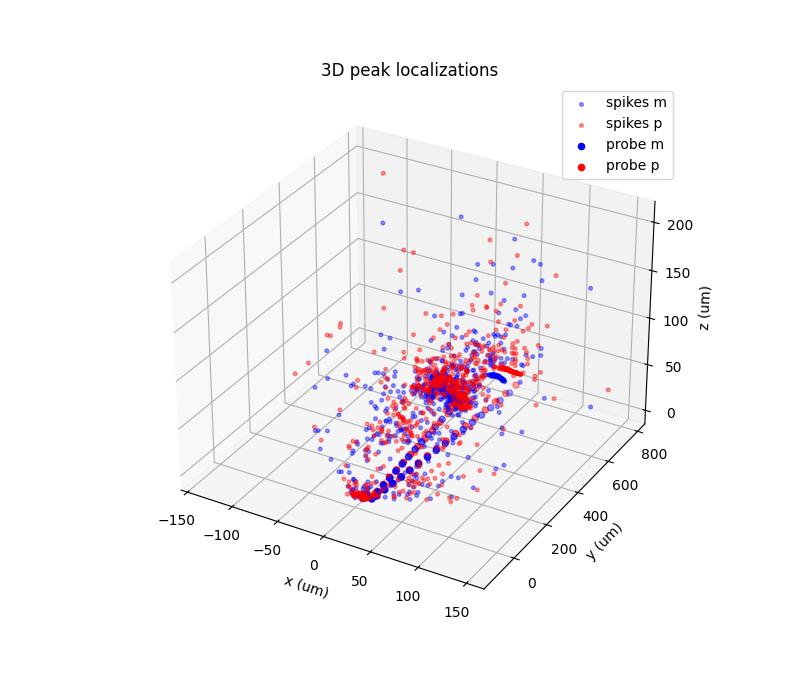

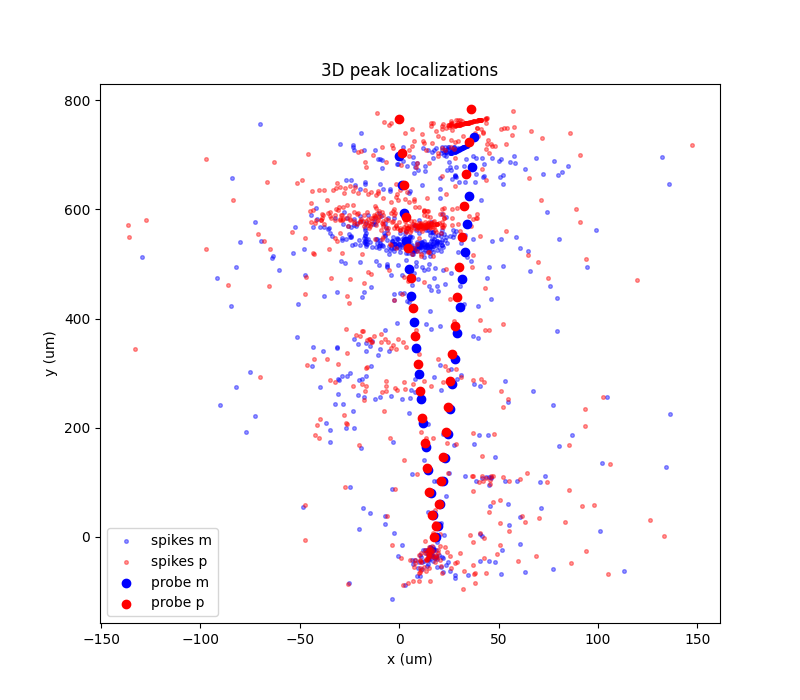

In [9]:
x_m = peak_locations_m['x'][0:700]
y_m = peak_locations_m['y'][0:700]
x_p = peak_locations_p['x'][0:700]
y_p = peak_locations_p['y'][0:700]

if len(peak_locations_m[0]) >= 3:
    z_m = peak_locations_m['z'][0:700]
    z_p = peak_locations_p['z'][0:700]

    if len(peak_locations_m[0]) == 4:
        alpha_m = peak_locations_m['alpha'][0:700]
        alpha_p = peak_locations_p['alpha'][0:700]

    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection="3d")

    ax.scatter(x_m, y_m, z_m, s=7, alpha=0.4, color='blue', label='spikes m')
    ax.scatter(x_p, y_p, z_p, s=7, alpha=0.4, color='red', label='spikes p')
    ax.scatter(probe_m_x, probe_m_y, np.zeros_like(probe_m_x), color='blue', label='probe m')
    ax.scatter(probe_p_x, probe_p_y, np.zeros_like(probe_p_x), color='red', label='probe p')


    ax.set_xlabel("x (um)")
    ax.set_ylabel("y (um)")
    ax.set_zlabel("z (um)")
    ax.set_title("3D peak localizations")
    ax.legend()

    plt.show()

plt.figure(figsize=(8, 7))

plt.scatter(x_m, y_m, s=7, alpha=0.4, color='blue', label='spikes m')
plt.scatter(x_p, y_p, s=7, alpha=0.4, color='red', label='spikes p')
plt.scatter(probe_m_x, probe_m_y, color='blue', label='probe m')
plt.scatter(probe_p_x, probe_p_y, color='red', label="probe p")

plt.xlabel("x (um)")
plt.ylabel("y (um)")
plt.title("3D peak localizations")
plt.legend()

plt.show()

Z: min dist: 1.0, max dist: 278.9025152767339


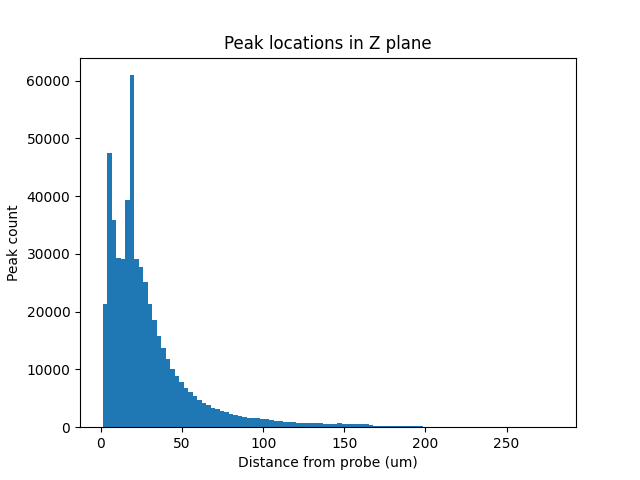

X: min dist: -136.44639587402344, max dist: 174.231689453125


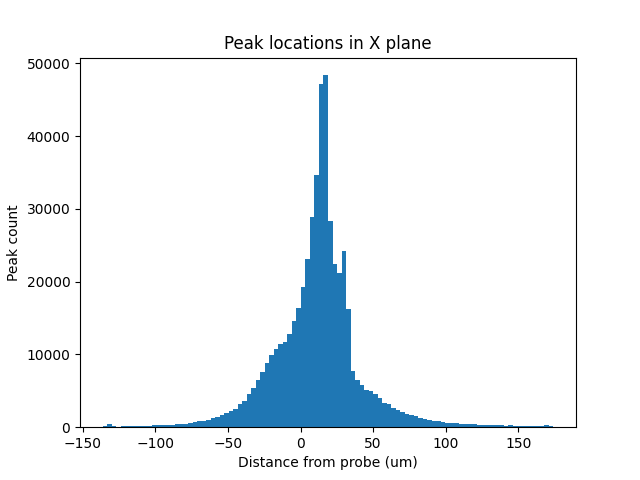

Y: min dist: -122.40516662597656, max dist: 800.8960620921457


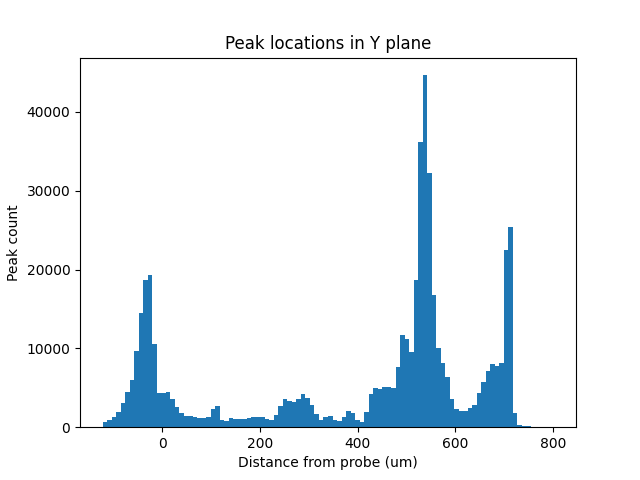

In [10]:
# plot the density or a histogram for each axis 

if len(peak_locations_m[0]) >= 3:
    print(f"Z: min dist: {np.min(peak_locations_m['z'])}, max dist: {np.max(peak_locations_m['z'])}")
    plt.figure()
    plt.hist(peak_locations_m['z'], bins=100)
    plt.xlabel("Distance from probe (um)")
    plt.ylabel("Peak count")
    plt.title("Peak locations in Z plane")
    plt.show()

print(f"X: min dist: {np.min(peak_locations_m['x'])}, max dist: {np.max(peak_locations_m['x'])}")
plt.figure()
plt.hist(peak_locations_m['x'], bins=100)
plt.xlabel("Distance from probe (um)")
plt.ylabel("Peak count")
plt.title("Peak locations in X plane")
plt.show()

print(f"Y: min dist: {np.min(peak_locations_m['y'])}, max dist: {np.max(peak_locations_m['y'])}")
plt.figure()
plt.hist(peak_locations_m['y'], bins=100)
plt.xlabel("Distance from probe (um)")
plt.ylabel("Peak count")
plt.title("Peak locations in Y plane")
plt.show()

In peaks array, we have access to the following information per peak:
1. sample index (gives us "time")
2. channel index (gives us "space" as defined by the probe (untrustworthy))
3. amplitude (gives "shape")
4. segment index (no idea what this is)

im curious about this streak and where it comes from. I will thus plot with color based on these different values (will plot also the different localization techniques too)

In [12]:
def plot_peak_locations(
    peak_locations,
    peaks,
    probe_x, 
    probe_y, 
    color_by="amplitude",
    n_peaks=700,
    plot_3d=True,
    cmap="viridis",
    s_spikes=7,
    alpha_spikes=0.6,
):
    """
    color_by: one of peaks fields or peak_locations fields
    """

    # Limit number of peaks
    loc = peak_locations[:n_peaks]
    pk = peaks[:n_peaks]

    x = loc["x"]
    y = loc["y"]

    has_z = "z" in loc.dtype.names
    z = loc["z"] if has_z else None

    # Choose color variable
    if color_by in pk.dtype.names:
        c = pk[color_by]
    elif color_by in loc.dtype.names:
        c = loc[color_by]
    else:
        raise ValueError(
            f"{color_by} not found. Available peaks fields: {pk.dtype.names}. "
            f"Available location fields: {loc.dtype.names}"
        )

    # ---------- 3D plot ----------
    if plot_3d and has_z:
        fig = plt.figure(figsize=(8, 7))
        ax = fig.add_subplot(111, projection="3d")

        sc = ax.scatter(
            x, y, z,
            c=c,
            cmap=cmap,
            s=s_spikes,
            alpha=alpha_spikes,
            label=f"spikes"
        )

        ax.scatter(
            probe_x, probe_y, np.zeros_like(probe_x),
            color="black",
            s=20,
            label=f"probe"
        )

        ax.set_xlabel("x (µm)")
        ax.set_ylabel("y (µm)")
        ax.set_zlabel("z (µm)")
        ax.set_title(f"3D peak localizations, colored by {color_by}")
        ax.legend()

        cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
        cbar.set_label(color_by)

        plt.show()

    # ---------- 2D plot ----------
    plt.figure(figsize=(8, 7))

    sc = plt.scatter(
        x, y,
        c=c,
        cmap=cmap,
        s=s_spikes,
        alpha=alpha_spikes,
        label=f"spikes"
    )

    plt.scatter(
        probe_x, probe_y,
        color="black",
        s=20,
        label=f"probe"
    )

    plt.xlabel("x (µm)")
    plt.ylabel("y (µm)")
    plt.title(f"2D peak localizations, colored by {color_by}")
    plt.legend()

    cbar = plt.colorbar(sc)
    cbar.set_label(color_by)

    plt.show()

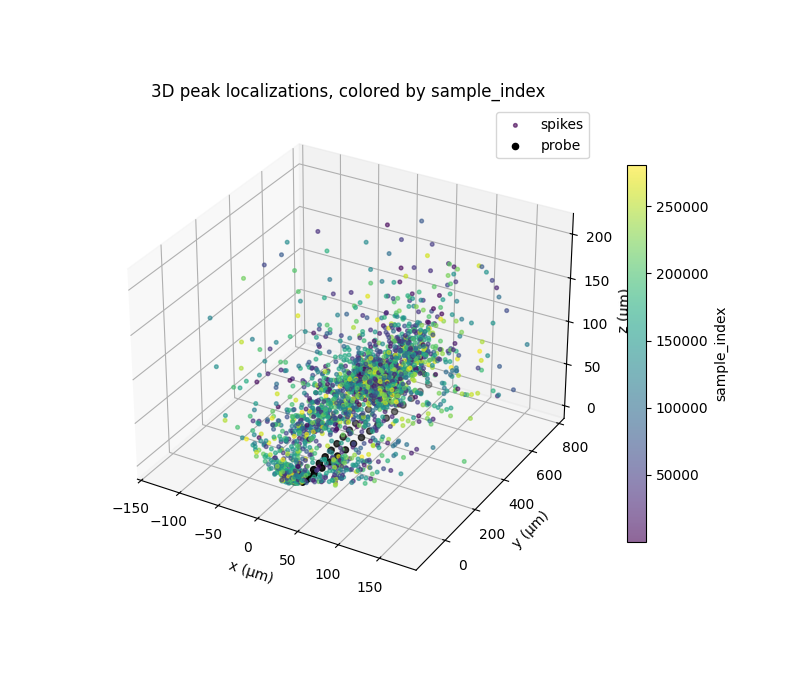

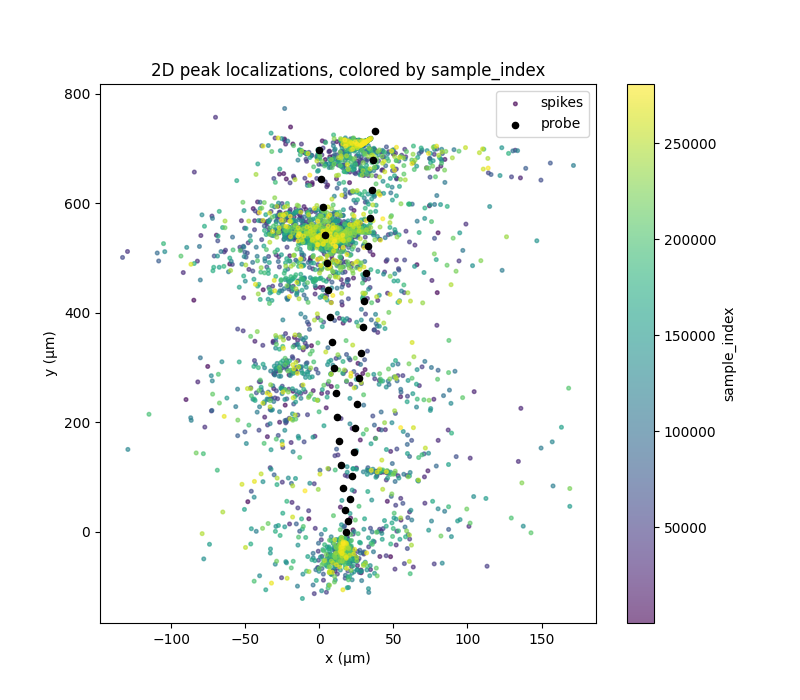

In [16]:
plot_peak_locations(peaks=peaks_m, peak_locations=peak_locations_m, probe_x=probe_m_x, probe_y=probe_m_y, color_by="sample_index", n_peaks=4000)

Why do bands appear in the peak locations? 
1. too few channels contribute: if localization uses only a small neighborhood or waveform is detected on only one channel then estimated position becomes almost channel position 
2. peak channel dominates the weight
3. geomtry is discrete in rows (bands become stronger if contact spacing is large relative to spatial spread of signal)

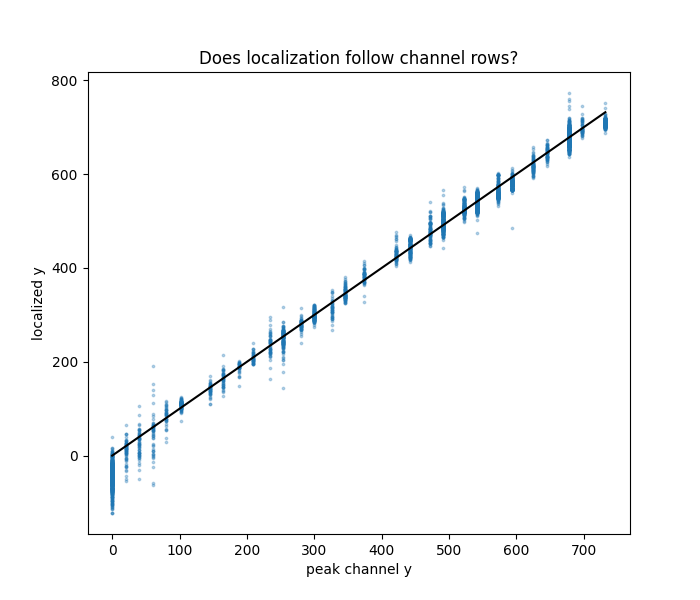

In [14]:
geom = prePros_m["P3_loc"].get_channel_locations()

peak_channel_y = geom[peaks_m["channel_index"][:7000], 1]
localized_y = peak_locations_m["y"][:7000]

plt.figure(figsize=(7, 6))
plt.scatter(peak_channel_y, localized_y, s=3, alpha=0.3)
plt.xlabel("peak channel y")
plt.ylabel("localized y")
plt.title("Does localization follow channel rows?")
plt.plot(
    [peak_channel_y.min(), peak_channel_y.max()],
    [peak_channel_y.min(), peak_channel_y.max()],
    color="black",
)
plt.show()

In [17]:
def compare_peak_locations_xy(
    loc_a,
    loc_b,
    label_a="grid_convolution",
    label_b="monopolar_triangulation",
    peaks=None,
    color_by=None,
    n_peaks=None,
    s=5,
    alpha=0.4,
    cmap="viridis",
):
    """
    Compare x,y localization of the same peaks across two methods.

    loc_a, loc_b: structured arrays with fields ["x", "y"]
    peaks: optional structured peaks array, used only for color_by
    color_by: optional field from peaks, loc_a, or loc_b
    """

    n = min(len(loc_a), len(loc_b))
    if n_peaks is not None:
        n = min(n, n_peaks)

    a = loc_a[:n]
    b = loc_b[:n]

    xa, ya = a["x"], a["y"]
    xb, yb = b["x"], b["y"]

    dx = xb - xa
    dy = yb - ya
    dist = np.sqrt(dx**2 + dy**2)

    # choose color variable
    if color_by is None:
        c = dist
        c_label = f"distance {label_b} - {label_a} (µm)"
    elif peaks is not None and color_by in peaks.dtype.names:
        c = peaks[color_by][:n]
        c_label = color_by
    elif color_by in a.dtype.names:
        c = a[color_by]
        c_label = f"{label_a} {color_by}"
    elif color_by in b.dtype.names:
        c = b[color_by]
        c_label = f"{label_b} {color_by}"
    else:
        raise ValueError("color_by not found in peaks, loc_a, or loc_b")

    # ---- summary ----
    print(f"Compared {n} peaks")
    print(f"median distance: {np.nanmedian(dist):.2f} µm")
    print(f"mean distance:   {np.nanmean(dist):.2f} µm")
    print(f"90th percentile: {np.nanpercentile(dist, 90):.2f} µm")
    print(f"max distance:    {np.nanmax(dist):.2f} µm")

    # ---- location overlay ----
    plt.figure(figsize=(7, 7))
    plt.scatter(xa, ya, s=s, alpha=alpha, label=label_a)
    plt.scatter(xb, yb, s=s, alpha=alpha, label=label_b)
    plt.xlabel("x (µm)")
    plt.ylabel("y (µm)")
    plt.title("XY localizations from both methods")
    plt.legend()
    plt.axis("equal")
    plt.show()

    # ---- displacement vectors ----
    plt.figure(figsize=(7, 7))
    sc = plt.scatter(xa, ya, c=c, s=s, alpha=alpha, cmap=cmap)
    plt.quiver(
        xa, ya, dx, dy,
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.002,
        alpha=0.25,
    )
    plt.xlabel(f"x {label_a} (µm)")
    plt.ylabel(f"y {label_a} (µm)")
    plt.title(f"Displacement vectors: {label_a} → {label_b}")
    plt.colorbar(sc, label=c_label)
    plt.axis("equal")
    plt.show()

    # ---- distance histogram ----
    plt.figure(figsize=(7, 4))
    plt.hist(dist, bins=100)
    plt.xlabel("XY distance between methods (µm)")
    plt.ylabel("count")
    plt.title(f"Distance: {label_a} vs {label_b}")
    plt.show()

    return {
        "dx": dx,
        "dy": dy,
        "distance": dist,
        "x_a": xa,
        "y_a": ya,
        "x_b": xb,
        "y_b": yb,
    }

Compared 5000 peaks
median distance: 21.10 µm
mean distance:   26.60 µm
90th percentile: 54.36 µm
max distance:    198.49 µm


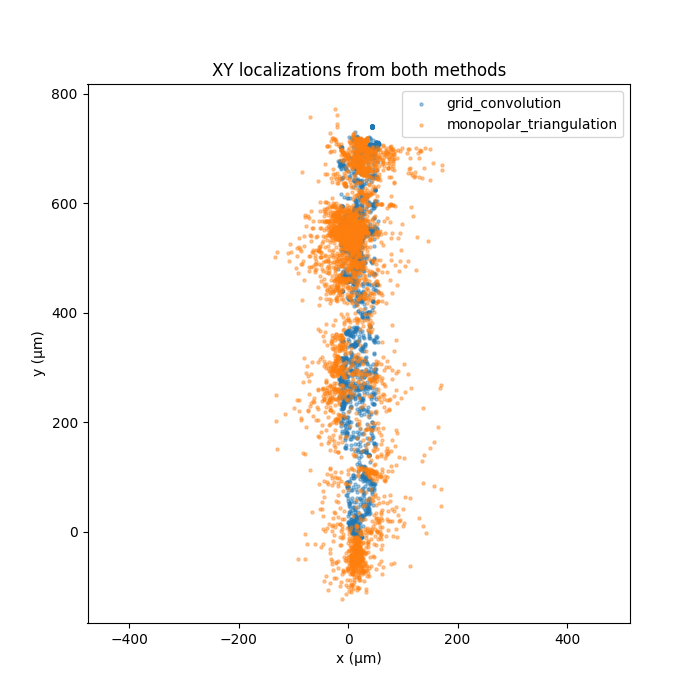

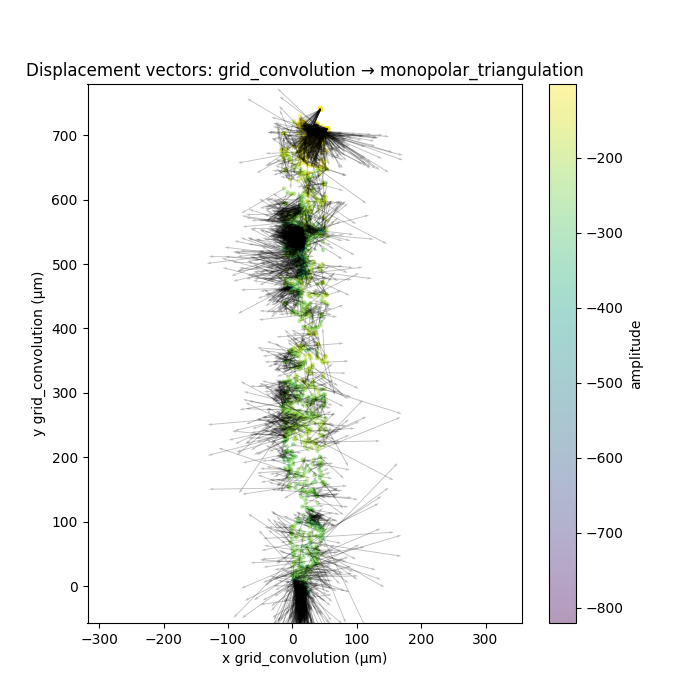

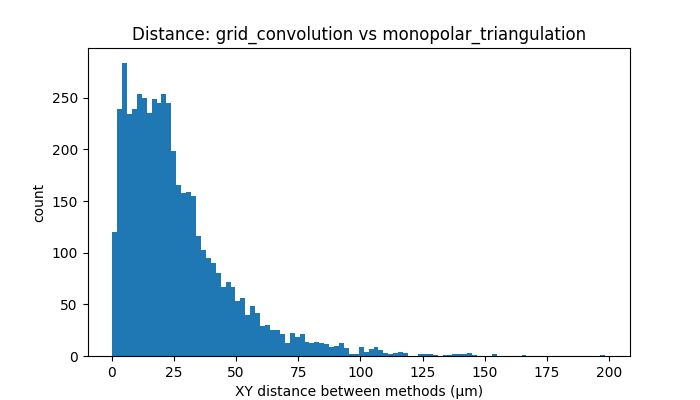

In [19]:
peak_locations_grid = np.load("Viktor_08/P3Loc_peak_locations_GC_20_m.npy")
peak_locations_monot = np.load("Viktor_08/P3Loc_peak_locations_MT_20_m.npy")
peaks = np.load("/Users/brunebettler/Desktop/Programming_Projects/NeuroTech/SpikeExplore/Viktor_08/npy/P3_local_peaks_thresh_20_m.npy")

comparison = compare_peak_locations_xy(
    loc_a=peak_locations_grid,
    loc_b=peak_locations_monot,
    label_a="grid_convolution",
    label_b="monopolar_triangulation",
    peaks=peaks,
    color_by="amplitude",
    n_peaks=5000,
)

***

In [ ]:
peak_locations_m = np.load("/Users/brunebettler/Desktop/Programming_Projects/NeuroTech/SpikeExplore/Viktor_08/P4Loc_peak_locations_GC_m.npy")
print(peak_locations_m.shape)
type(peak_locations_m[0])

peak_locations_m_x = peak_locations_m['x']
peak_locations_m_y = peak_locations_m['y']
peak_locations_m_z = peak_locations_m['z']


In [43]:
x_min = np.min(peak_locations_m_x)
x_max = np.max(peak_locations_m_x)
y_min = np.min(peak_locations_m_y)
y_max = np.max(peak_locations_m_y)
z_min = np.min(peak_locations_m_z)
z_max = np.max(peak_locations_m_z)

print(f"x: min = {x_min}, max = {x_max}, values over {x_max + np.abs(x_min)} um.") 
print(f"y: min = {y_min}, max = {y_max}, values over {y_max + np.abs(y_min)} um.") 
print(f"z: min = {z_min}, max = {z_max}, values over {z_max + np.abs(z_min)} um.") 

x: min = -19.99369239807129, max = 57.75750732421875, values over 77.75119972229004 um.
y: min = -19.307233810424805, max = 741.5477905273438, values over 760.8550243377686 um.
z: min = 0.0, max = 120.00000762939453, values over 120.00000762939453 um.


In [ ]:
import hdbscan
from sklearn.preprocessing import StandardScaler

def make_features(peak_locations, peaks=None):
    X = np.column_stack([
        peak_locations["x"],
        peak_locations["y"],
        peak_locations["z"] if "z" in peak_locations.dtype.names else np.zeros(len(peak_locations)),
    ])

    # optional: add amplitude if available
    if peaks is not None and "amplitude" in peaks.dtype.names:
        amp = np.abs(peaks["amplitude"])
        X = np.column_stack([X, np.log1p(amp)])

    return StandardScaler().fit_transform(X)


X_m = make_features(peak_locations_m, peaks=common_peaks)
X_p = make_features(peak_locations_p, peaks=common_peaks)

clusterer_m = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=20,
)

clusterer_p = hdbscan.HDBSCAN(
    min_cluster_size=100,
    min_samples=20,
)

labels_m = clusterer_m.fit_predict(X_m)
labels_p = clusterer_p.fit_predict(X_p)

: 

In [6]:
# all arrays above have the same number of peaks but different location estimates. 

peak_locations_GC_m = np.load("peak_locations_GC_m.npy") # 3D
peak_locations_GC_p = np.load("peak_locations_GC_p.npy")

peak_locations_COM_m = np.load("peak_locations_COM_m.npy") # 2D
peak_locations_COM_p = np.load("peak_locations_COM_p.npy")

def structured_to_array(a, fields=None):
    if fields is None:
        fields = a.dtype.names
    return np.column_stack([a[f] for f in fields])

GC_m = structured_to_array(peak_locations_GC_m[:1000], fields=["x", "y", "z"])
GC_p = structured_to_array(peak_locations_GC_p[:1000], fields=["x", "y", "z"])

COM_m = structured_to_array(peak_locations_COM_m[:1000], fields=["x", "y"])
COM_p = structured_to_array(peak_locations_COM_p[:1000], fields=["x", "y"])

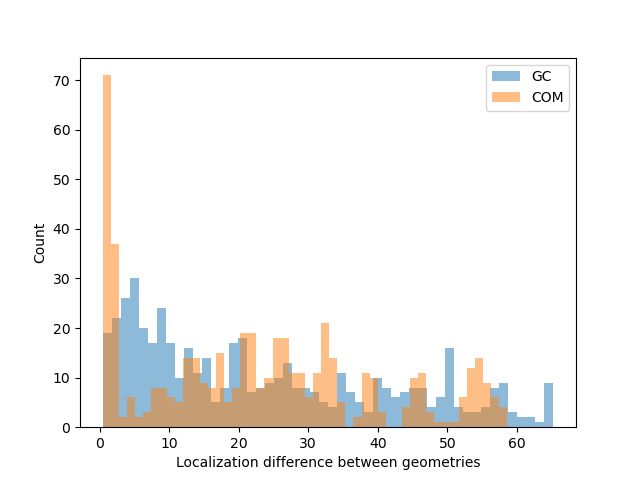

In [16]:
# determine the distances between the two spike location arrays 

# sample a random subset of peaks for distance calculation
sample_size = 500
indices = np.random.choice(len(GC_m), size=sample_size, replace=False)

d_GC = np.linalg.norm(GC_m[indices] - GC_p[indices], axis=1)
d_COM = np.linalg.norm(COM_m[indices] - COM_p[indices], axis=1)

plt.figure()
plt.hist(d_GC, bins=50, alpha=0.5, label="GC")
plt.hist(d_COM, bins=50, alpha=0.5, label="COM")
plt.xlabel("Localization difference between geometries")
plt.ylabel("Count")
plt.legend()
plt.show()

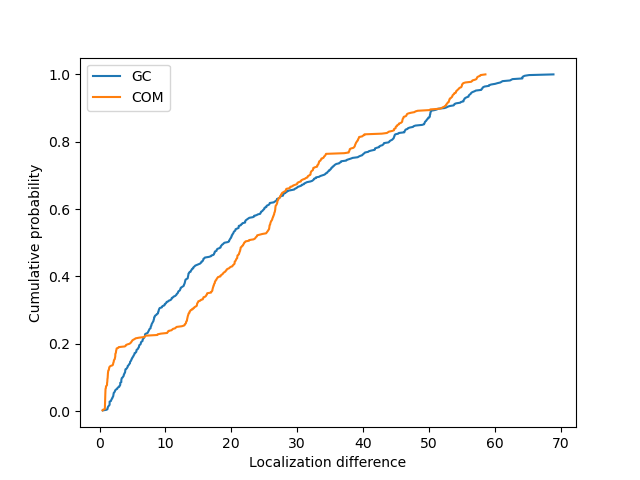

In [10]:
def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y

x_gc, y_gc = ecdf(d_GC)
x_com, y_com = ecdf(d_COM)

plt.figure()
plt.plot(x_gc, y_gc, label="GC")
plt.plot(x_com, y_com, label="COM")
plt.xlabel("Localization difference")
plt.ylabel("Cumulative probability")
plt.legend()
plt.show()

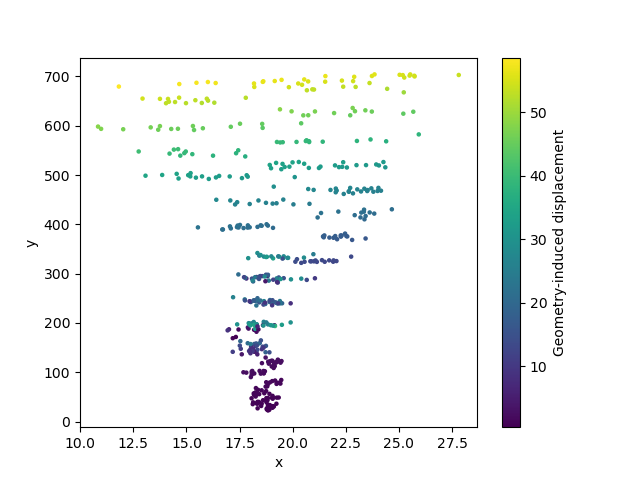

In [18]:
plt.figure()
plt.scatter(
    COM_m[indices, 0],
    COM_m[indices, 1],
    c=d_COM,
    s=5
)
plt.xlabel("x")
plt.ylabel("y")
plt.colorbar(label="Geometry-induced displacement")
plt.show()

For each geometry × sorter, compute:

number of units
number of good units after QC
median firing rate
median SNR
ISI violation rate
amplitude cutoff
presence ratio
isolation distance / nearest-neighbor metrics, if available

SpikeInterface has quality metrics for this purpose. The docs describe compute_quality_metrics() as the main interface for per-unit sorting quality assessment

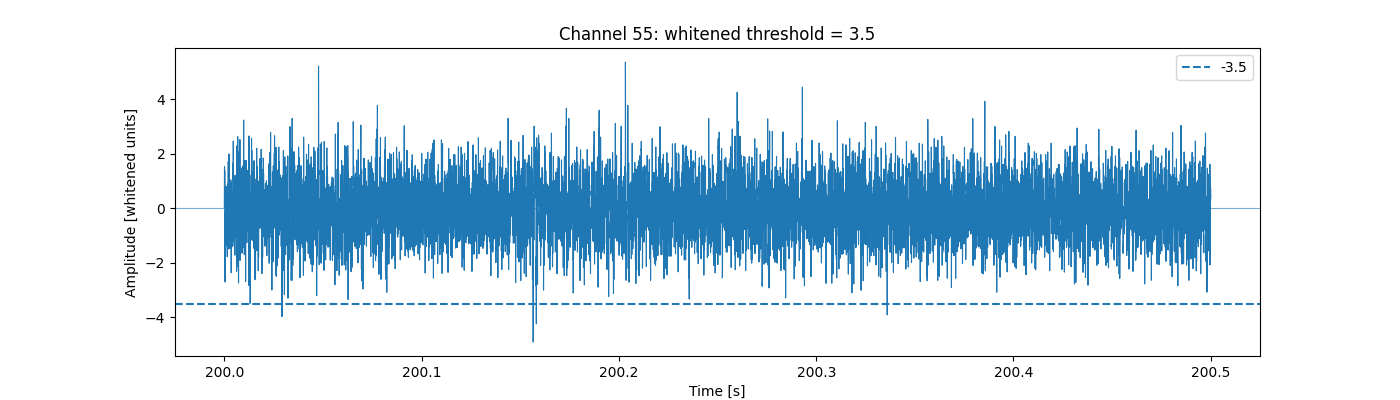

In [10]:
# determine the adequate threshold 
def plot_zscore_threshold_trace(
    rec_z,
    channel_id,
    start_s=10,
    duration_s=1,
    threshold=5.0,
    peak_sign="neg",
):
    fs = rec_z.get_sampling_frequency()
    start_frame = int(start_s * fs)
    end_frame = int((start_s + duration_s) * fs)

    trace = rec_z.get_traces(
        start_frame=start_frame,
        end_frame=end_frame,
        channel_ids=[channel_id],
        return_scaled=False,
    )[:, 0]

    t = np.arange(trace.size) / fs + start_s

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t, trace, lw=0.8)

    if peak_sign in ("neg", "both"):
        ax.axhline(-threshold, linestyle="--", lw=1.5, label=f"-{threshold}")
        ax.fill_between(t, trace, -threshold, where=trace < -threshold, alpha=0.25)

    if peak_sign in ("pos", "both"):
        ax.axhline(threshold, linestyle="--", lw=1.5, label=f"+{threshold}")
        ax.fill_between(t, trace, threshold, where=trace > threshold, alpha=0.25)

    ax.axhline(0, lw=0.8, alpha=0.6)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Amplitude [z-score units]")
    ax.set_title(f"Channel {channel_id}: threshold = {threshold}")
    ax.legend()
    plt.show()


def plot_whitened_threshold_trace(
    rec_w,
    channel_id,
    start_s=10,
    duration_s=1,
    threshold=5.0,
    peak_sign="neg",
):
    fs = rec_w.get_sampling_frequency()
    start_frame = int(start_s * fs)
    end_frame = int((start_s + duration_s) * fs)

    trace = rec_w.get_traces(
        start_frame=start_frame,
        end_frame=end_frame,
        channel_ids=[channel_id],
        return_in_uV=False,
    )[:, 0]

    t = np.arange(trace.size) / fs + start_s

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(t, trace, lw=0.8)

    if peak_sign in ("neg", "both"):
        ax.axhline(-threshold, linestyle="--", lw=1.5, label=f"-{threshold}")
        ax.fill_between(
            t,
            trace,
            -threshold,
            where=trace < -threshold,
            alpha=0.25,
            interpolate=True,
        )

    if peak_sign in ("pos", "both"):
        ax.axhline(threshold, linestyle="--", lw=1.5, label=f"+{threshold}")
        ax.fill_between(
            t,
            trace,
            threshold,
            where=trace > threshold,
            alpha=0.25,
            interpolate=True,
        )

    ax.axhline(0, lw=0.8, alpha=0.6)
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Amplitude [whitened units]")
    ax.set_title(f"Channel {channel_id}: whitened threshold = {threshold}")
    ax.legend()
    plt.show()

"""plot_zscore_threshold_trace(
    P4_z,
    channel_id=P4_z.channel_ids[10],
    start_s=200,
    duration_s=0.5,
    threshold=3.5,
    peak_sign="neg",
)"""

plot_whitened_threshold_trace(
    prePros_m["P4_loc"],
    channel_id=prePros_m["P4_loc"].channel_ids[0],
    start_s=200,
    duration_s=0.5,
    threshold=3.5,
    peak_sign="neg",
)

In [6]:
import os 
import spikeinterface.sorters as ss

ss.installed_sorters()
ss.get_default_sorter_params("simple")

simple_params = {
 'apply_preprocessing': False,
 'freq_min': 300.0,
 'freq_max': 5000.0,
 'peak_sign': 'neg',
 'detect_threshold': 3.5, # try 4 as done earlier 
 'ms_before': 0.5,
 'ms_after': 1.5,
 'n_svd_components_per_channel': 5,
 'clusterer': 'hdbscan',
 'clusterer_kwargs': {},
 'seed': 0,
 'job_kwargs': {"progress_bar": True}}

In [7]:
start_frame = 0 
end_frame = int(15 * 60 * 20000) # 15 minutes of data

recording_15min_m = prePros_m["P4_z"].frame_slice(
    start_frame=start_frame,
    end_frame=end_frame,
)

recording_15min_p = prePros_p["P4_z"].frame_slice(
    start_frame=start_frame,
    end_frame=end_frame,
)

recording_15min_l = prePros_l["P4_z"].frame_slice(
    start_frame=start_frame,
    end_frame=end_frame,
)

In [7]:
sorting_simple_m = ss.run_sorter(
    sorter_name="simple",
    recording=prePros_m["P4_loc"],
    folder=os.path.join("Sortings", "simple_probe_m"),
    remove_existing_folder=True,
    verbose=True,
    raise_error=True, 
    **simple_params)

print("probe m units:", len(sorting_simple_m.get_unit_ids()))

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks (locally_exclusive) (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

Simple sorter found 554347 peaks in total


Fit peaks svd (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

Transform peaks svd (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

simple run time 1555.42s
probe m units: 2


In [8]:
sorting_simple_l = ss.run_sorter(
    sorter_name="simple",
    recording=prePros_l["P4_loc"],
    folder=os.path.join("Sortings", "simple_probe_l"),
    remove_existing_folder=True,
    verbose=True,
    raise_error=True, 
    **simple_params)

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks (locally_exclusive) (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

Simple sorter found 571667 peaks in total


Fit peaks svd (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

Transform peaks svd (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

simple run time 1600.47s


In [11]:
sorting_simple_p = ss.run_sorter(
    sorter_name="simple",
    recording=recording_15min_p,
    folder=os.path.join("Sortings", "simple_probe_p"),
    remove_existing_folder=True,
    verbose=True,
    raise_error=True, 
    **simple_params)



detect peaks (locally_exclusive) (no parallelization):   0%|          | 0/900 [00:00<?, ?it/s]

Simple sorter found 153051 peaks in total


Fit peaks svd (no parallelization):   0%|          | 0/900 [00:00<?, ?it/s]

Transform peaks svd (no parallelization):   0%|          | 0/900 [00:00<?, ?it/s]

simple run time 158.59s


In [ ]:

print("probe l units:", len(sorting_simple_l.get_unit_ids()))
print("probe p units:", len(sorting_simple_p.get_unit_ids()))

import spikeinterface.comparison as sc

cmp = sc.compare_two_sorters(
    sorting1=sorting_simple_m,
    sorting2=sorting_simple_p,
    sorting1_name="simple_probe_m",
    sorting2_name="simple_probe_p",
)

print(cmp.agreement_scores)

probe m units: 2
probe l units: 2
probe p units: 2
     0         1
0  0.0  0.000040
1  0.0  0.778902


In [9]:
import spikeinterface.full as si

analyzer_m = si.create_sorting_analyzer(
    sorting=sorting_simple_m,
    recording=recording_15min_l,
    format="memory",
)
analyzer_m.compute("random_spikes")
analyzer_m.compute("waveforms")
analyzer_m.compute("templates")
analyzer_m.compute("noise_levels")
analyzer_m.compute("spike_amplitudes")
analyzer_m.compute("unit_locations")
analyzer_m.compute("correlograms")
analyzer_m.compute('template_similarity')

estimate_sparsity (no parallelization):   0%|          | 0/900 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/900 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/900 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/postprocessing/template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


In [ ]:
import spikeinterface.widgets as sw

sw.plot_sorting_summary(analyzer_m, backend="spikeinterface_gui")

: 

***
## mountainsort5

In [11]:
import spikeinterface.sorters as ss

MS5_params = {
    "filter": False,
    "whiten": False,
    "n_jobs": 4,
    "chunk_duration": "2s",
    "progress_bar": True,
    "detect_threshold": 7,
    "detect_sign": -1,
    "detect_time_radius_msec": 0.5,

    "snippet_T1": 20,
    "snippet_T2": 20,

    "npca_per_channel": 3,
    "snippet_mask_radius": 150,

    "scheme2_phase1_detect_channel_radius": 150,
    "scheme2_detect_channel_radius": 100
}

sorting_MS5_m = ss.run_sorter(
    sorter_name="mountainsort5",
    recording=prePros_m["P4_loc"],
    folder="Sortings/MS5_probe_m",
    remove_existing_folder=True,
    verbose=True,
    **MS5_params
)

write_binary_recording 
engine=process - n_jobs=4 - samples_per_chunk=40,000 - chunk_memory=4.58 MiB - total_memory=18.31 MiB - chunk_duration=2.00s


/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/sorters/external/mountainsort5.py:147: UserWarning: Not whitening (MountainSort5 expects whitened data)
  warn("Not whitening (MountainSort5 expects whitened data)")


write_binary_recording (workers: 4 processes spawn):   0%|          | 0/900 [00:00<?, ?it/s]

Using training recording of duration 300 sec with the sampling mode uniform
*** MS5 Elapsed time for SCHEME2 get_sampled_recording_for_training: 0.756 seconds ***
Running phase 1 sorting
Number of channels: 30
Number of timepoints: 6000000
Sampling frequency: 20000.0 Hz
Channel 0: [ 37.75 732.  ]
Channel 1: [  0. 698.]
Channel 2: [ 36.53225807 678.        ]
Channel 3: [  1.21774194 645.        ]
Channel 4: [ 35.31451613 625.        ]
Channel 5: [  2.43548387 593.        ]
Channel 6: [ 34.0967742 573.       ]
Channel 7: [  3.65322581 542.        ]
Channel 8: [ 32.87903226 522.        ]
Channel 9: [  4.87096774 491.        ]
Channel 10: [ 31.66129033 472.        ]
Channel 11: [  6.08870968 442.        ]
Channel 12: [ 30.44354839 422.        ]
Channel 13: [ 29.22580645 374.        ]
Channel 14: [  8.52419355 346.        ]
Channel 15: [ 28.00806452 326.        ]
Channel 16: [  9.74193549 299.        ]
Channel 17: [ 26.79032258 280.        ]
Channel 18: [ 10.95967742 253.        ]
Channel 1

In [14]:
sorting_MS5_l = ss.run_sorter(
    sorter_name="mountainsort5",
    recording=prePros_l["P4_loc"],
    folder="Sortings/MS5_probe_l",
    remove_existing_folder=True,
    verbose=True,
    **MS5_params
)
print(f"Units detected: {len(sorting_MS5_l.get_unit_ids())}")

write_binary_recording 
engine=process - n_jobs=4 - samples_per_chunk=40,000 - chunk_memory=4.58 MiB - total_memory=18.31 MiB - chunk_duration=2.00s


/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/sorters/external/mountainsort5.py:147: UserWarning: Not whitening (MountainSort5 expects whitened data)
  warn("Not whitening (MountainSort5 expects whitened data)")


write_binary_recording (workers: 4 processes spawn):   0%|          | 0/900 [00:00<?, ?it/s]

Using training recording of duration 300 sec with the sampling mode uniform
*** MS5 Elapsed time for SCHEME2 get_sampled_recording_for_training: 0.838 seconds ***
Running phase 1 sorting
Number of channels: 30
Number of timepoints: 6000000
Sampling frequency: 20000.0 Hz
Channel 0: [ 37.75 732.  ]
Channel 1: [  0. 698.]
Channel 2: [ 36.53225807 678.        ]
Channel 3: [  1.21774194 645.        ]
Channel 4: [ 35.31451613 625.        ]
Channel 5: [  2.43548387 593.        ]
Channel 6: [ 34.0967742 573.       ]
Channel 7: [  3.65322581 542.        ]
Channel 8: [ 32.87903226 522.        ]
Channel 9: [  4.87096774 491.        ]
Channel 10: [ 31.66129033 472.        ]
Channel 11: [  6.08870968 442.        ]
Channel 12: [ 30.44354839 422.        ]
Channel 13: [ 29.22580645 374.        ]
Channel 14: [  8.52419355 346.        ]
Channel 15: [ 28.00806452 326.        ]
Channel 16: [  9.74193549 299.        ]
Channel 17: [ 26.79032258 280.        ]
Channel 18: [ 10.95967742 253.        ]
Channel 1

In [17]:
import spikeinterface.full as si

analyzers = {}

for name, sorting, recording in zip(
    ["m", "l"],
    [sorting_MS5_m, sorting_MS5_l],
    [prePros_m["P4_loc"], prePros_l["P4_loc"]],
):
    analyzer = si.create_sorting_analyzer(
        sorting=sorting,
        recording=recording,
        format="memory",
    )

    analyzer.compute("random_spikes")
    analyzer.compute("waveforms")
    analyzer.compute("templates")
    analyzer.compute("noise_levels")
    analyzer.compute("spike_amplitudes")
    analyzer.compute("unit_locations")
    analyzer.compute("correlograms")
    analyzer.compute("template_similarity")

    analyzers[name] = analyzer

estimate_sparsity (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

estimate_sparsity (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def summarize_and_plot_analyzers(analyzers):
    summaries = {}

    for name, analyzer in analyzers.items():
        sorting = analyzer.sorting
        unit_ids = np.array(sorting.unit_ids)

        # ---------- spike counts ----------
        spike_counts = np.array([
            len(sorting.get_unit_spike_train(unit_id))
            for unit_id in unit_ids
        ])

        summary = pd.DataFrame({
            "unit_id": unit_ids,
            "n_spikes": spike_counts,
        })

        # ---------- unit locations ----------
        loc_ext = analyzer.get_extension("unit_locations")
        unit_locations = loc_ext.get_data()

        summary["x"] = unit_locations[:, 0]
        summary["y"] = unit_locations[:, 1]

        summaries[name] = summary

        # ---------- plot unit locations ----------
        fig, ax = plt.subplots(figsize=(5, 8))
        sc = ax.scatter(
            summary["x"],
            summary["y"],
            s=np.sqrt(summary["n_spikes"]) * 3,
            c=summary["n_spikes"],
        )

        for _, row in summary.iterrows():
            ax.text(row["x"], row["y"], str(row["unit_id"]), fontsize=8)

        ax.set_title(f"{name}: unit locations")
        ax.set_xlabel("x [µm]")
        ax.set_ylabel("y [µm]")
        ax.invert_yaxis()
        plt.colorbar(sc, ax=ax, label="Spike count")
        plt.show()

        # ---------- plot spike counts ----------
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.bar(summary["unit_id"].astype(str), summary["n_spikes"])
        ax.set_title(f"{name}: spikes per unit")
        ax.set_xlabel("Unit ID")
        ax.set_ylabel("Spike count")
        ax.tick_params(axis="x", rotation=90)
        plt.tight_layout()
        plt.show()

        # ---------- plot average waveforms/templates ----------
        templates_ext = analyzer.get_extension("templates")
        templates = templates_ext.get_data()

        channel_locs = analyzer.recording.get_channel_locations()
        n_units = len(unit_ids)

        for i, unit_id in enumerate(unit_ids):
            template = templates[i]  # shape: samples x channels

            peak_chan = np.argmax(np.ptp(template, axis=0))
            waveform = template[:, peak_chan]

            fs = analyzer.recording.get_sampling_frequency()
            t_ms = np.arange(waveform.size) / fs * 1000

            fig, ax = plt.subplots(figsize=(5, 3))
            ax.plot(t_ms, waveform)
            ax.axhline(0, lw=0.8, alpha=0.5)

            ax.set_title(
                f"{name}: unit {unit_id}, peak chan {analyzer.recording.channel_ids[peak_chan]}"
            )
            ax.set_xlabel("Time [ms]")
            ax.set_ylabel("Amplitude")
            plt.tight_layout()
            plt.show()

    return summaries

In [20]:
import spikeinterface.exporters as sexp

sexp.export_to_phy(
    analyzers['l'],
    output_folder="/Volumes/Trenholm2/neuroTechData/sortings/phy_ms5_L",
    compute_pc_features=True,
    compute_amplitudes=True,
    remove_if_exists=True,
)

write_binary_recording (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/6 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/6 [00:00<?, ?it/s]

extract PCs (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

Run:
phy template-gui  /Volumes/Trenholm2/neuroTechData/sortings/phy_ms5_L/params.py


***
## Spykingcircuis 2

In [21]:
import spikeinterface.sorters as ss

SKC2_params = {
    "general": {"ms_before": 0.5, "ms_after": 1.5, "radius_um": 100.0},
        "filtering": {"freq_min": 150, "freq_max": 7000, "ftype": "bessel", "filter_order": 2},
        "whitening": {"mode": "local", "regularize": False},
        "detection": {
            "method": "matched_filtering",
            "method_kwargs": dict(peak_sign="neg", detect_threshold=3.5),
            "pipeline_kwargs": dict(),
        },
        "selection": {
            "method": "uniform",
            "method_kwargs": dict(n_peaks_per_channel=5000, min_n_peaks=100000, select_per_channel=False),
        },
        "apply_motion_correction": False,
        "motion_correction": {"preset": "dredge_fast"},
        "merging": {"max_distance_um": 50},
        "clustering": {"method": "iterative-hdbscan", "method_kwargs": dict()},
        "cleaning": {"min_snr": 5, "max_jitter_ms": 0.2, "sparsify_threshold": 1, "mean_sd_ratio_threshold": 3},
        "min_firing_rate": 0.1,
        "matching": {"method": "circus-omp", "method_kwargs": dict(), "pipeline_kwargs": dict()},
        "apply_preprocessing": False,
        "apply_whitening": False,
        "cache_preprocessing": {"mode": "memory", "memory_limit": 0.5},
        "chunk_preprocessing": {"memory_limit": None},
        "multi_units_only": False,
        "job_kwargs": {},
        "seed": 42,
        "deterministic_peaks_detection": False,
        "debug": False,
}

In [ ]:
sorting_SKC2_m = ss.run_sorter(
    sorter_name="spykingcircus2",
    recording=prePros_m["P4_loc"],
    folder="Sortings/SKC2_probe_m",
    remove_existing_folder=True,
    verbose=True,
    **SKC2_params
)

sorting_SKC2_l = ss.run_sorter(
    sorter_name="spykingcircus2",
    recording=prePros_l["P4_loc"],
    folder="Sortings/SKC2_probe_l",
    remove_existing_folder=True,
    verbose=True,
    **SKC2_params
)

Skipping preprocessing (no whitening)


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/sortingcomponents/tools.py:424: UserWarning: Recording too large to be preloaded in RAM...
  warnings.warn("Recording too large to be preloaded in RAM...")


get protoype waveforms (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

detect peaks (matched_filtering) 
engine=process - n_jobs=1 - samples_per_chunk=20,000 - chunk_memory=2.29 MiB - total_memory=2.29 MiB - chunk_duration=1.00s


...

split_clusters with local_feature_clustering:   0%|          | 0/30 [00:00<?, ?it/s]

Removed 0 empty templates
Removed 0 unaligned templates
Removed 28 templates with too low SNR
Removed 0 templates with too high mean sd / noise ratio
Kept 6 raw clusters
Kept 6 non-duplicated clusters
Removed 0 empty templates
Removed 0 unaligned templates
Removed 0 templates with too low SNR
Removed 0 templates with too high mean sd / noise ratio
remove_small_cluster: kept  2 removed 4 (min_spike_count 179)
Kept 2 clean clusters
find spikes (circus-omp) 
engine=process - n_jobs=1 - samples_per_chunk=20,000 - chunk_memory=2.29 MiB - total_memory=2.29 MiB - chunk_duration=1.00s


/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/core/baserecordingsnippets.py:259: UserWarning: There is no Probe attached to this recording. Creating a dummy one with contact positions
  warn("There is no Probe attached to this recording. Creating a dummy one with contact positions")
/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/core/baserecordingsnippets.py:259: UserWarning: There is no Probe attached to this recording. Creating a dummy one with contact positions
  warn("There is no Probe attached to this recording. Creating a dummy one with contact positions")


find spikes (circus-omp) (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

Found 584428 spikes
Kept 2 units after final merging
spykingcircus2 run time 416.75s


In [25]:
import spikeinterface.full as si

analyzers = {}

for name, sorting, recording in zip(
    ["m", "l"],
    [sorting_MS5_m, sorting_MS5_l],
    [prePros_m["P4_loc"], prePros_l["P4_loc"]],
):
    analyzer = si.create_sorting_analyzer(
        sorting=sorting,
        recording=recording,
        format="memory",
    )

    analyzer.compute("random_spikes")
    analyzer.compute("waveforms")
    analyzer.compute("templates")
    analyzer.compute("noise_levels")
    analyzer.compute("spike_amplitudes")
    analyzer.compute("unit_locations")
    analyzer.compute("correlograms")
    analyzer.compute("template_similarity")

    analyzers[name] = analyzer


summaries = summarize_and_plot_analyzers(analyzers)

estimate_sparsity (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

KeyboardInterrupt: 

***

In [ ]:
traces = prePros_m["P3_loc"].get_traces(return_in_uV=True)

C = np.corrcoef(traces.T)
mask = np.triu(np.ones_like(C, dtype=bool))

C_masked = np.ma.masked_where(mask, C)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(C_masked, aspect="equal", origin="lower", vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(np.arange(len(clean_channel_ids)))
ax.set_yticks(np.arange(len(clean_channel_ids)))

ax.set_xticklabels(clean_channel_ids, rotation=90)
ax.set_yticklabels(clean_channel_ids)

ax.set_xlabel("Channel ID")
ax.set_ylabel("Channel ID")
ax.set_title("LFP channel correlation")

fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

what we're seeing could be the polarity inversion across cortical layers 
oscillations :) 

channels within groups behave like neighbors 

In [12]:
sw.plot_traces(KS_P4, channel_ids=clean_channel_ids[:], return_in_uV=True, backend="ipywidgets")


/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/preprocessing/whiten.py:141: RuntimeWarning: divide by zero encountered in matmul
  whiten_traces = traces @ self.W
/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/preprocessing/whiten.py:141: RuntimeWarning: overflow encountered in matmul
  whiten_traces = traces @ self.W
/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/spikeinterface/preprocessing/whiten.py:141: RuntimeWarning: invalid value encountered in matmul
  whiten_traces = traces @ self.W


AppLayout(children=(TimeSlider(children=(Dropdown(description='Segment', options=(0,), value=0), Button(icon='…

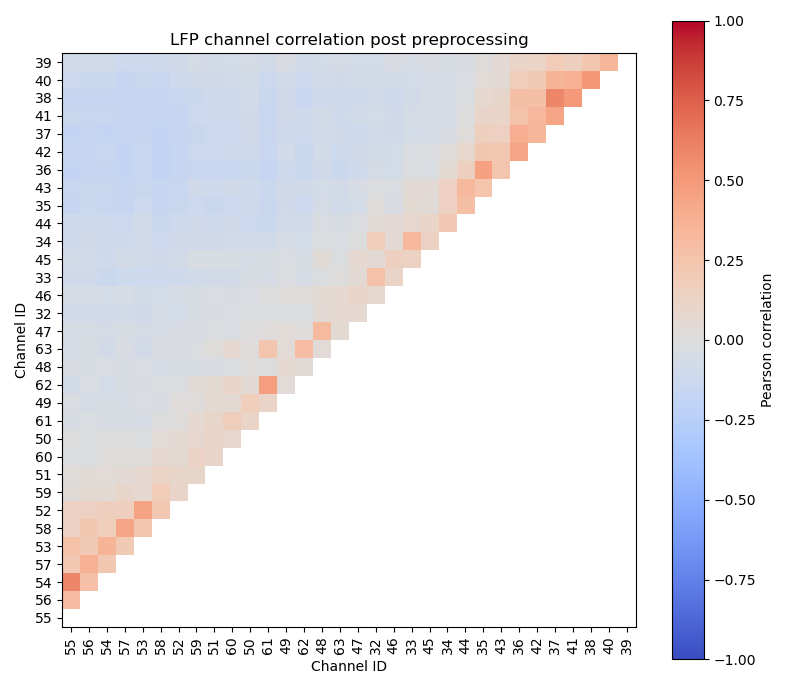

In [13]:
traces_preprocessed = KS_P3.get_traces(channel_ids=clean_channel_ids[:], start_frame=0, end_frame=10000, return_in_uV=True)  

C = np.corrcoef(traces_preprocessed.T)
mask = np.triu(np.ones_like(C, dtype=bool))

C_masked = np.ma.masked_where(mask, C)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(C_masked, aspect="equal", origin="lower", vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(np.arange(len(clean_channel_ids)))
ax.set_yticks(np.arange(len(clean_channel_ids)))

ax.set_xticklabels(clean_channel_ids, rotation=90)
ax.set_yticklabels(clean_channel_ids)

ax.set_xlabel("Channel ID")
ax.set_ylabel("Channel ID")
ax.set_title("LFP channel correlation post preprocessing")

fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

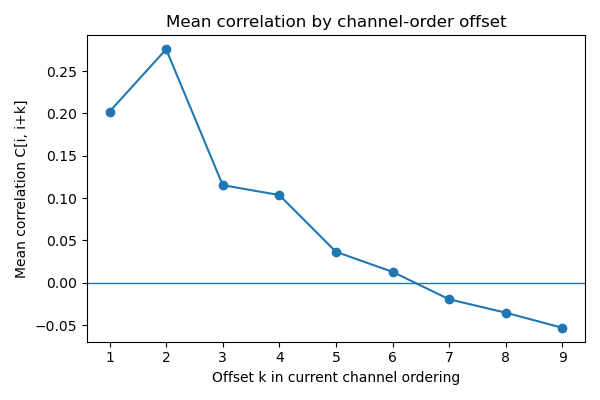

In [14]:
import numpy as np
import matplotlib.pyplot as plt

offset_corr = []

for k in range(1, 10):
    vals = []
    for i in range(len(C) - k):
        vals.append(C[i, i + k])
    offset_corr.append(np.mean(vals))

ks = np.arange(1, 10)

plt.figure(figsize=(6, 4))
plt.plot(ks, offset_corr, marker="o")
plt.axhline(0, linewidth=1)
plt.xlabel("Offset k in current channel ordering")
plt.ylabel("Mean correlation C[i, i+k]")
plt.title("Mean correlation by channel-order offset")
plt.xticks(ks)
plt.tight_layout()
plt.show()

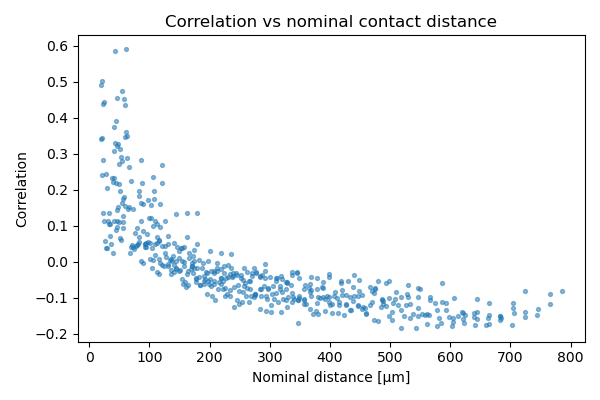

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

coords = np.c_[result.ends[:, 0], result.ends[:, 1]]
D = squareform(pdist(coords))

tri = np.triu_indices_from(D, k=1)

plt.figure(figsize=(6, 4))
plt.scatter(D[tri], C[tri], s=8, alpha=0.5)
plt.xlabel("Nominal distance [µm]")
plt.ylabel("Correlation")
plt.title("Correlation vs nominal contact distance")
plt.tight_layout()
plt.show()

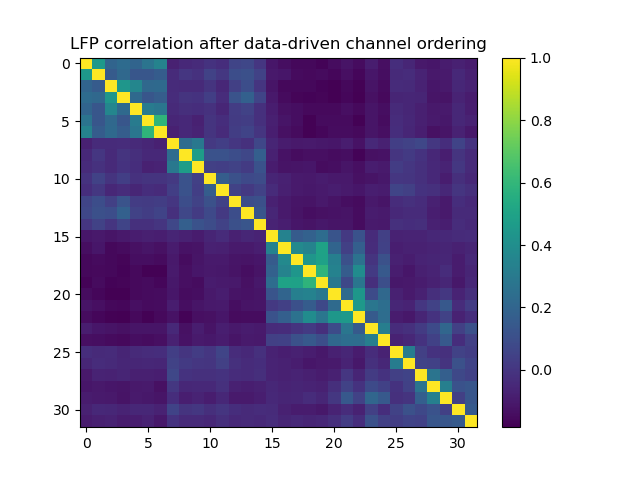

In [16]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

dist = 1 - C
np.fill_diagonal(dist, 0)

Z = linkage(squareform(dist, checks=False), method="average")
order = leaves_list(Z)

plt.figure()
plt.imshow(C[np.ix_(order, order)], aspect="auto")
plt.colorbar()
plt.title("LFP correlation after data-driven channel ordering")
plt.show()

In [18]:
job_kwargs = dict(n_jobs=-1, progress_bar=True, chunk_duration="1s")

sorting_analyzer = si.create_sorting_analyzer(sorting_MS5, clean_recording)

sorting_analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)
sorting_analyzer.compute("waveforms", **job_kwargs)
sorting_analyzer.compute("templates", **job_kwargs)
sorting_analyzer.compute("noise_levels")
sorting_analyzer.compute("unit_locations", method="monopolar_triangulation")
sorting_analyzer.compute("isi_histograms")
sorting_analyzer.compute("correlograms", window_ms=100, bin_ms=5.)
sorting_analyzer.compute("principal_components", n_components=3, mode='by_channel_global', whiten=True, **job_kwargs)
sorting_analyzer.compute("quality_metrics", metric_names=["snr", "firing_rate"])
sorting_analyzer.compute("template_similarity")
sorting_analyzer.compute("spike_amplitudes", **job_kwargs)

estimate_sparsity (no parallelization):   0%|          | 0/3433 [00:00<?, ?it/s]

compute_waveforms (workers: 12 processes spawn):   0%|          | 0/3433 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Fitting PCA:   0%|          | 0/7 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/7 [00:00<?, ?it/s]

/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/sklearn/decomposition/_base.py:152: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/opt/miniconda3/envs/spike_env/lib/python3.11/site-packages/skl

spike_amplitudes (workers: 12 processes spawn):   0%|          | 0/3433 [00:00<?, ?it/s]

In [ ]:
sw.plot_sorting_summary(sorting_analyzer, backend="spikeinterface_gui")

: 

In [1]:
sorting_HS = ss.run_sorter(
    sorter_name="herdingspikes",
    recording=KS_P3,
    folder="SI_SortingResults/HS_May_18_2026",
    remove_existing_folder=True,
    verbose=True,
)



NameError: name 'ss' is not defined

In [9]:
job_kwargs = dict(n_jobs=-1, progress_bar=True, chunk_duration="1s")

sorting_analyzer = si.create_sorting_analyzer(sorting_HS, clean_recording)

sorting_analyzer.compute("random_spikes", method="uniform", max_spikes_per_unit=500)
sorting_analyzer.compute("waveforms", **job_kwargs)
sorting_analyzer.compute("templates", **job_kwargs)
sorting_analyzer.compute("noise_levels")
sorting_analyzer.compute("unit_locations", method="monopolar_triangulation")
sorting_analyzer.compute("isi_histograms")
sorting_analyzer.compute("correlograms", window_ms=100, bin_ms=5.)
sorting_analyzer.compute("principal_components", n_components=3, mode='by_channel_global', whiten=True, **job_kwargs)
sorting_analyzer.compute("quality_metrics", metric_names=["snr", "firing_rate"])
sorting_analyzer.compute("template_similarity")
sorting_analyzer.compute("spike_amplitudes", **job_kwargs)

estimate_sparsity (no parallelization):   0%|          | 0/3795 [00:00<?, ?it/s]

compute_waveforms (workers: 32 processes spawn):   0%|          | 0/3795 [00:00<?, ?it/s]

Fitting PCA:   0%|          | 0/163 [00:00<?, ?it/s]

Projecting waveforms:   0%|          | 0/163 [00:00<?, ?it/s]

spike_amplitudes (workers: 32 processes spawn):   0%|          | 0/3795 [00:00<?, ?it/s]

In [10]:
sw.plot_sorting_summary(sorting_analyzer, backend="spikeinterface_gui")

In [ ]:
sorting_TDC = ss.run_sorter(
    sorter_name="tridesclous",
    recording=KS_P3,
    folder="SI_SortingResults/TDC_May_18_2026",
    remove_existing_folder=True,
    verbose=True)

Local copy of recording


write_binary_recording (no parallelization):   0%|          | 0/3795 [00:00<?, ?it/s]

***

## Kilosort4




In [ ]:
import spikeinterface.sorters as ss

KS4_params = {
  'batch_size': 120000, 
  'nblocks': 0, 
  'Th_universal': 3, 
  'Th_learned': 4, 
  'nt': 41, 
  'shift': None, 
  'scale': None, 
  'batch_downsampling': 1, 
  'artifact_threshold': np.inf, 
  'nskip': 25, 
  'whitening_range': 32, 
  'highpass_cutoff': 300, 
  'binning_depth': 5, 
  'sig_interp': 20, 
  'drift_smoothing': [0.5, 0.5, 0.5], 
  'nt0min': None, 
  'dmin': None, 
  'dminx': 32, # TODO 5 
  'min_template_size': 10, 
  'template_sizes': 5, 
  'nearest_chans': 10, # TODO 4 
  'nearest_templates': 100, 
  'max_channel_distance': 32, # TODO 5 
  'max_peels': 100, 
  'templates_from_data': True, 
  'n_templates': 6, 
  'n_pcs': 6, 
  'Th_single_ch': 6, # TODO 3.5 
  'acg_threshold': 0.2, # TODO 0.15
  'ccg_threshold': 0.25, # TODO 0.2
  'cluster_neighbors': 10, # TODO 5 
  'cluster_downsampling': 20, 
  'max_cluster_subset': 25000, 
  'x_centers': None, 
  'cluster_init_seed': 5, 
  'duplicate_spike_ms': 0.25, 
  'position_limit': 100, 
  'do_CAR': False, 
  'invert_sign': False, 
  'save_extra_vars': False, 
  'save_preprocessed_copy': False, 
  'torch_device': 'auto', 
  'bad_channels': None, 
  'clear_cache': False, 
  'do_correction': False, 
  'skip_kilosort_preprocessing': True, 
  'keep_good_only': False, 
  'use_binary_file': True, 
  'delete_recording_dat': True, 
  'pool_engine': 'process', 
  'n_jobs': 1, 
  'chunk_duration': '1s', 
  'progress_bar': True, 
  'mp_context': None, 
  'max_threads_per_worker': 1}

In [ ]:
sorting_KS4_m = ss.run_sorter(
    sorter_name="kilosort4",
    recording=prePros_m["P4_loc"],
    folder="Sortings/KS4_probe_m",
    remove_existing_folder=True,
    verbose=True, 
    **KS4_params)

write_binary_recording (no parallelization):   0%|          | 0/1800 [00:00<?, ?it/s]

kilosort.run_kilosort:  
kilosort.run_kilosort: Computing drift correction.
kilosort.run_kilosort: ----------------------------------------
kilosort.datashift: nblocks = 0, skipping drift correction
kilosort.run_kilosort: drift computed in 0.00s; total 0.01s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after drift correction
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:    100.00 %
kilosort.run_kilosort: Mem used:     67.60 %     |      16.23 GB
kilosort.run_kilosort: Mem avail:     7.77 / 24.00 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    N/A
kilosort.run_kilosort: GPU memory:   N/A
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort:  
kilosort.run_kilosort: Extracting spikes using templates
kilosort.run_kilosort: ----------------------------------------
kilosort.spikedetect: Re

Skipping common average reference.
Skipping kilosort preprocessing.


kilosort.spikedetect: Number of universal templates: 210
kilosort.spikedetect: Detecting spikes...
100%|██████████| 300/300 [10:18<00:00,  2.06s/it]
kilosort.run_kilosort: 2223786 spikes extracted in 631.05s; total 631.07s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after spike detect (univ)
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:     0.00 %
kilosort.run_kilosort: Mem used:     66.80 %     |      16.04 GB
kilosort.run_kilosort: Mem avail:     7.96 / 24.00 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    N/A
kilosort.run_kilosort: GPU memory:   N/A
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort:  
kilosort.run_kilosort: First clustering
kilosort.run_kilosort: ----------------------------------------
  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
sorting_KS4_l = ss.run_sorter(
    sorter_name="kilosort4",
    recording=prePros_l["P4_loc"],
    folder="Sortings/KS4_probe_l",
    remove_existing_folder=True,
    verbose=True, 
    **KS4_params)